In [ ]:
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

# Tracking AI Trends Through NLP-Powered Text Mining
Authors: Gupta Vani, Lazaridis Alkiviadis, Van Helleputte Cyriel
## Stage 2: Advanced Embedding Models Training and Analysis

This notebook implements the second phase of the project pipeline:

1. Data Preparation for Embeddings
2. Classical Word Embeddings
3. Document Embedding
4. Intrinsic Evaluation
5. Fine Tuning Open Models
6. Overall Comparative Evaluation
7. Insight Extraction & Trend Analysis
8. Summary
9. Conclusion


The goal is to develop and evaluate embedding and language models tailored to the AI Media Dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd

try:

  df = pd.read_csv("/content/drive/MyDrive/MyDrive/CLT/processed_ai_media_dataset.csv")

except FileNotFoundError as e:
  !gdown 1DzMXv0YryfYeu3nZneS_3NE4Zv5dUD2h
  df = pd.read_csv("processed_ai_media_dataset.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1DzMXv0YryfYeu3nZneS_3NE4Zv5dUD2h
From (redirected): https://drive.google.com/uc?id=1DzMXv0YryfYeu3nZneS_3NE4Zv5dUD2h&confirm=t&uuid=2711acfd-c5b2-4183-b3a8-742b12b4169e
To: /content/processed_ai_media_dataset.csv
100% 472M/472M [00:06<00:00, 77.4MB/s]


In [ ]:
import ast

df["tokens"] = df["tokens"].apply(ast.literal_eval)

In [ ]:
df["tokens"].iloc[0][:10]

['digit',
 'humanoid',
 'distribution',
 'retail',
 'manufacture',
 'logistics',
 'source',
 'agility',
 'robotics',
 'robotics']

In [ ]:
type(df["tokens"].iloc[0])

list

## 1. Enhanced Data Preparation for Embeddings

**1.1 Acronym Normalization:**
To improve consistency in the vocabulary, common acronyms are replaced with their full forms

In [ ]:
acronym_map = {

    #AI terminology
    r"\blarge language models?\b": "LLM",
    r"\bllms?\b": "LLM",

    r"\bnatural language processing\b": "NLP",
    r"\bnlp\b": "NLP",

    r"\bartificial intelligence\b": "AI",
    r"\bai\b": "AI",

    r"\bmachine learning\b": "ML",
    r"\bml\b": "ML",

    r"\bgenerative ai\b": "GenAI",

    r"\bartificial general intelligence\b": "AGI",

    #Geography short forms
    r"\bunited states\b": "US",
    r"\bu\.s\.a?\.\b": "US",

    r"\bunited kingdom\b": "UK",
    r"\bu\.k\.\b": "UK",

    r"\beuropean union\b": "EU",
    r"\be\.u\.\b": "EU"
}

In [ ]:
def normalize_acronyms(tokens):
    return [acronym_map.get(token, token) for token in tokens]

df["tokens_acronym_norm"] = df["tokens"].apply(normalize_acronyms)

**1.2 Bigram / Phrase Detection:**

Many important AI concepts consist of multiple words.
Using Gensim's phrase detection, frequently co-occurring word pairs are merged into single tokens.This helps embeddings capture meaningful technical concepts as single semantic units.

In [ ]:
!pip install gensim
from gensim.models.phrases import Phrases, Phraser

sentences = df["tokens_acronym_norm"].tolist()

# detect common phrases
bigram = Phrases(sentences, min_count=20, threshold=10)
bigram_model = Phraser(bigram)

# apply bigram model
sentences_bigram = [bigram_model[s] for s in sentences]

df["tokens_bigram"] = sentences_bigram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.4 MB/s eta 0:00:00


**1.3 Rare Word Filtering:**

Very infrequently used words often add noise to embedding models and increase vocabulary size.  
To improve training efficiency and representation quality, tokens appearing fewer than a specified threshold are removed from the corpus.

In [ ]:
from collections import Counter

# count word frequencies
word_counts = Counter(
    word for sentence in df["tokens_bigram"] for word in sentence
)

pd.Series(word_counts).describe()


,0
count,136894.000000
mean,85.807282
std,854.560485
min,1.000000
25%,1.000000
50%,3.000000
75%,14.000000
max,150190.000000


Based on the distribution, a threshold of 5 is chosen.

In [ ]:
def remove_rare_words(tokens):
    return [word for word in tokens if word_counts[word] >= 5]

df["tokens_enhanced"] = df["tokens_bigram"].apply(remove_rare_words)

In [ ]:
baseline_vocab = set(word for sent in df["tokens"] for word in sent)
enhanced_vocab = set(word for sent in df["tokens_enhanced"] for word in sent)

print("Baseline vocabulary size:", len(baseline_vocab))
print("Enhanced vocabulary size:", len(enhanced_vocab))

Baseline vocabulary size: 125054
Enhanced vocabulary size: 54109


## 2. Classical Word Embeddings

Using the preprocessed corpus, we train classical word embedding models to learn semantic
relationships between words in the AI media dataset. Word embeddings map words to dense
vector representations where semantically similar words appear close together in the
embedding space.

In [ ]:
sentences = df["tokens_enhanced"].tolist()

print("Number of documents:", len(sentences))
print("Example sentence:", sentences[0][:20])

Number of documents: 16452
Example sentence: ['digit', 'humanoid', 'distribution', 'retail', 'manufacture_logistics', 'source', 'agility_robotics', 'robotics', 'week', 'announce_partnership', 'ricoh', 'usa', 'global', 'service', 'delivery', 'organization', 'ricoh', 'expand', 'capabilities', 'throughout']


### 2.1 Train Word2Vec *(Run only once)*

Word2Vec learns word representations by predicting surrounding context words within a sliding window. Words appearing in similar contexts obtain similar vector representations.

In [ ]:
# from gensim.models import Word2Vec

# w2v_model = Word2Vec(
#     sentences=sentences,
#     vector_size=100,
#     window=5,
#     min_count=5,
#     workers=4
# )

# print("Vocabulary size:", len(w2v_model.wv))

### 3.2 Train FastText *(Run only Once)*

FastText extends Word2Vec by representing words as combinations of character n-grams.
This allows the model to better handle rare or previously unseen words.

In [ ]:
# from gensim.models import FastText

# ft_model = FastText(
#     sentences=sentences,
#     vector_size=100,
#     window=5,
#     min_count=5,
#     workers=4
# )

# print("Vocabulary size:", len(ft_model.wv))

### 2.3 Saving and Loading the Models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# w2v_model.save("/content/drive/MyDrive/MyDrive/CLT/Phase2_Models/word2vec.model")
# ft_model.save("//content/drive/MyDrive/MyDrive/CLT/Phase2_Models/fasttext.model")

In [ ]:
from gensim.models import Word2Vec, FastText
try:
  w2v_model = Word2Vec.load("/content/drive/MyDrive/CLT/Phase2_Models/word2vec.model")
  ft_model = FastText.load("/content/drive/MyDrive/CLT/Phase2_Models/fasttext.model")
except:
  #https://drive.google.com/file/d/1D7yrDlSSO5MOJq8niUPGrjU4wtfVu6qz/view?usp=sharing #w2v
  #https://drive.google.com/file/d/1Iaq4B6Jsre6LRvhC-Lyvq6A74Tgyf9bA/view?usp=sharing #ft
  #https://drive.google.com/file/d/1ncrATalQEZCI7Wc_Wk5zBs8_kaD1PrB0/view?usp=sharing #.npy
  #https://drive.google.com/file/d/1nH-WZyX5OCrymw_ac8WdR9KY-tC76gyh/view?usp=sharing #d2v

  !gdown 1D7yrDlSSO5MOJq8niUPGrjU4wtfVu6qz
  w2v_model = Word2Vec.load("word2vec.model")
  !gdown 1Iaq4B6Jsre6LRvhC-Lyvq6A74Tgyf9bA
  !gdown 1ncrATalQEZCI7Wc_Wk5zBs8_kaD1PrB0
  ft_model = FastText.load("fasttext.model")


### 2.4 Visualize Embedding Cluster

To explore semantic relationships between terms, we reduce the embedding dimensions using t-SNE and visualize the word vectors in a two-dimensional space.

In [ ]:
import numpy as np


In [ ]:
words_w2v = w2v_model.wv.index_to_key[:1000]
words_ft = ft_model.wv.index_to_key[:1000]

vectors_w2v = np.array([w2v_model.wv[w] for w in words_w2v])
vectors_ft = np.array([ft_model.wv[w] for w in words_ft])

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=81)

reduced_w2v = tsne.fit_transform(vectors_w2v)
reduced_ft = tsne.fit_transform(vectors_ft)

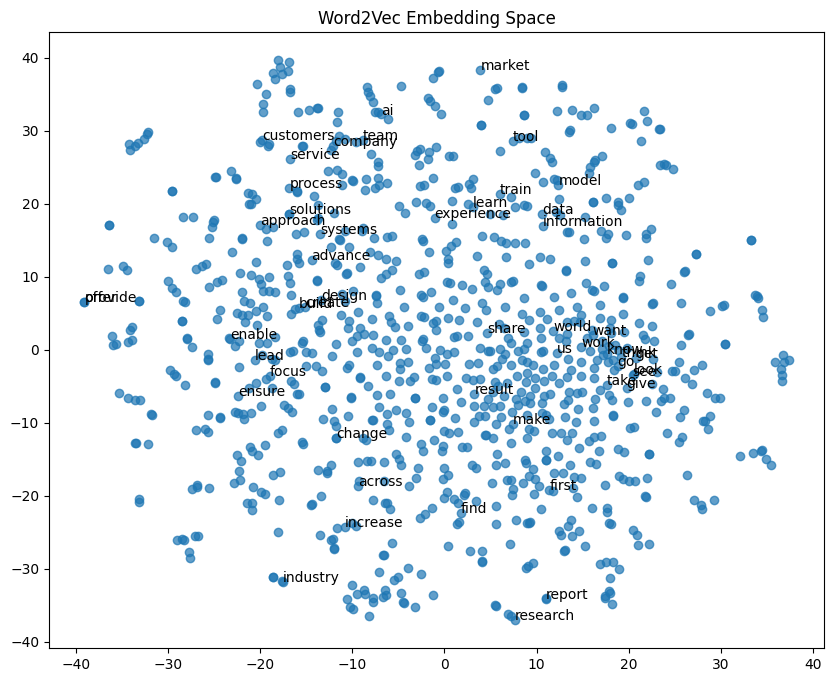

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(reduced_w2v[:,0], reduced_w2v[:,1], alpha=0.7)

for i, word in enumerate(words_w2v[:50]):
    plt.annotate(word, (reduced_w2v[i,0], reduced_w2v[i,1]))

plt.title("Word2Vec Embedding Space")
plt.show()

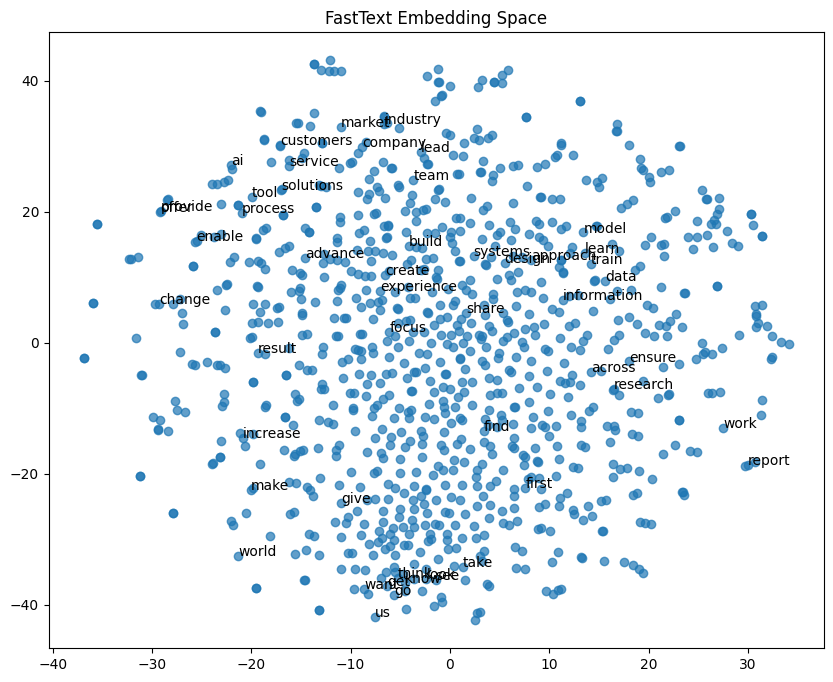

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(reduced_ft[:,0], reduced_ft[:,1], alpha=0.7)

for i, word in enumerate(words_ft[:50]):
    plt.annotate(word, (reduced_ft[i,0], reduced_ft[i,1]))

plt.title("FastText Embedding Space")
plt.show()

## 3. Document Embeddings

### 3.1 Train Doc2Vec *(Run only Once)*

Doc2Vec learns vector representations for entire documents (articles), allowing us to analyze similarity between AI-related media texts.

In [ ]:
# from gensim.models.doc2vec import TaggedDocument
# from gensim.models import Doc2Vec

# tagged_docs = [
#     TaggedDocument(words=row["tokens_enhanced"], tags=[str(i)])
#     for i, row in df.iterrows()
# ]

# d2v_model = Doc2Vec(
#     tagged_docs,
#     vector_size=100,
#     window=5,
#     min_count=5,
#     workers=4
# )

### 3.2 Save and Load Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# d2v_model.save("/content/drive/MyDrive/CLT/Phase2_Models/doc2vec.model")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from gensim.models import Doc2Vec
try:
  d2v_model = Doc2Vec.load("/content/drive/MyDrive/CLT/Phase2_Models/doc2vec.model")
except:
  !gdown 1nH-WZyX5OCrymw_ac8WdR9KY-tC76gyh
  d2v_model = Doc2Vec.load("doc2vec.model")

### 3.3 Clustering using Document Embeddings

In [ ]:
from sklearn.cluster import KMeans

doc_vectors = np.array([d2v_model.dv[i] for i in range(len(df))])

kmeans = KMeans(n_clusters=10, random_state=81)
clusters = kmeans.fit_predict(doc_vectors)

df["cluster"] = clusters

for c in range(10):
    print("\nCluster", c)
    print(df[df.cluster==c]["title"].head())


Cluster 0
19    Techniques to Enhance Precision in Machine Lea...
20    Navigating the Annotation Interface in Label S...
22    Market Basket Analysis Using High Utility Item...
23    A Step-by-Step Guide to Build a Graph Learning...
40    How I’ ve Been Creating My Own Pull Request Co...
Name: title, dtype: object

Cluster 1
15    Making the Leap from Pharmaceuticals to Privat...
21    Agentic AI in Healthcare: Revolutionizing Pati...
44    Advancing cancer treatments: PhoreMost extends...
95                              Health IT Business News
97    Turbine Achieves Key Milestone in Collaboratio...
Name: title, dtype: object

Cluster 2
1     AI Design Trends to Watch in 2025: From Photor...
26              Is Your User Base Growing or Shrinking?
27    MTV VMAs 2024: Live shopping is coming to the ...
37    With AI, agencies advance CTV contextual targe...
43    Google Pixel Watch 3: Updated Daily Readiness ...
Name: title, dtype: object

Cluster 3
29    With China seeking AI dominan

We can observe some patterns within the articles in each cluster. For example,


*   Cluster 3 seems to encompass articles related to political and geographical positions with respect to AI.
*   The article titles in Cluster 9 suggest thought pieces and opininon pieces about AI rather than factual or technologically-oriented articles.



In [ ]:
cluster_labels = {}

for c in sorted(df["cluster"].unique()):
    tokens = []

    for row in df[df.cluster == c]["tokens_enhanced"]:
        tokens.extend(row)

    top_words = [w for w,_ in Counter(tokens).most_common(3)]

    cluster_labels[c] = ", ".join(top_words)

print(cluster_labels)

{np.int32(0): 'model, data, train', np.int32(1): 'ai, data, healthcare', np.int32(2): 'ai, market, content', np.int32(3): 'china, ai, unite_state', np.int32(4): 'ai, model, data', np.int32(5): 'stock, ai, market', np.int32(6): 'ai, data, process', np.int32(7): 'ai, quantum, data', np.int32(8): 'ai, data, model', np.int32(9): 'ai, think, get'}


In [ ]:
!pip install umap-learn

In [ ]:
import umap
import numpy as np


umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=81)

doc_vectors_2d = umap_model.fit_transform(doc_vectors)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


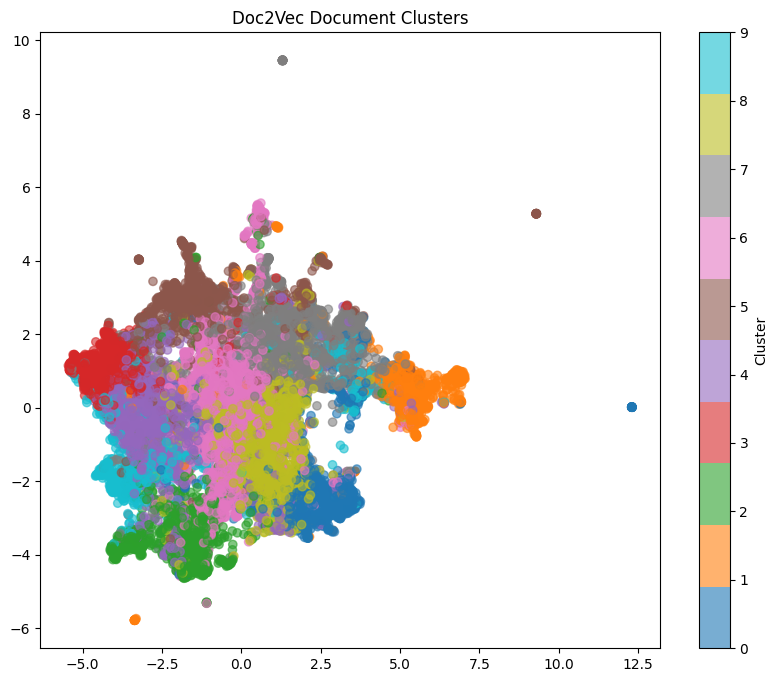

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    doc_vectors_2d[:,0],
    doc_vectors_2d[:,1],
    c=df["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.title("Doc2Vec Document Clusters")

plt.colorbar(scatter, label="Cluster")
plt.show()

To interpret the document clusters, we extract representative keywords from each cluster by aggregating all tokens belonging to documents within the cluster and selecting the three most frequent terms. These keywords provide a rough semantic summary of the topics discussed in each group of articles and are used to label the clusters in the visualization.

For example, the clusters containing terms such as model, data, train likely corresponds to technological discussions of AI model development.

In [ ]:
cluster_labels = {}

for c in sorted(df["cluster"].unique()):
    tokens = []

    for row in df[df.cluster == c]["tokens_enhanced"]:
        tokens.extend(row)

    top_words = [w for w,_ in Counter(tokens).most_common(3)]

    cluster_labels[c] = ", ".join(top_words)

print(cluster_labels)

{np.int32(0): 'model, data, train', np.int32(1): 'ai, data, healthcare', np.int32(2): 'ai, market, content', np.int32(3): 'china, ai, unite_state', np.int32(4): 'ai, model, data', np.int32(5): 'stock, ai, market', np.int32(6): 'ai, data, process', np.int32(7): 'ai, quantum, data', np.int32(8): 'ai, data, model', np.int32(9): 'ai, think, get'}


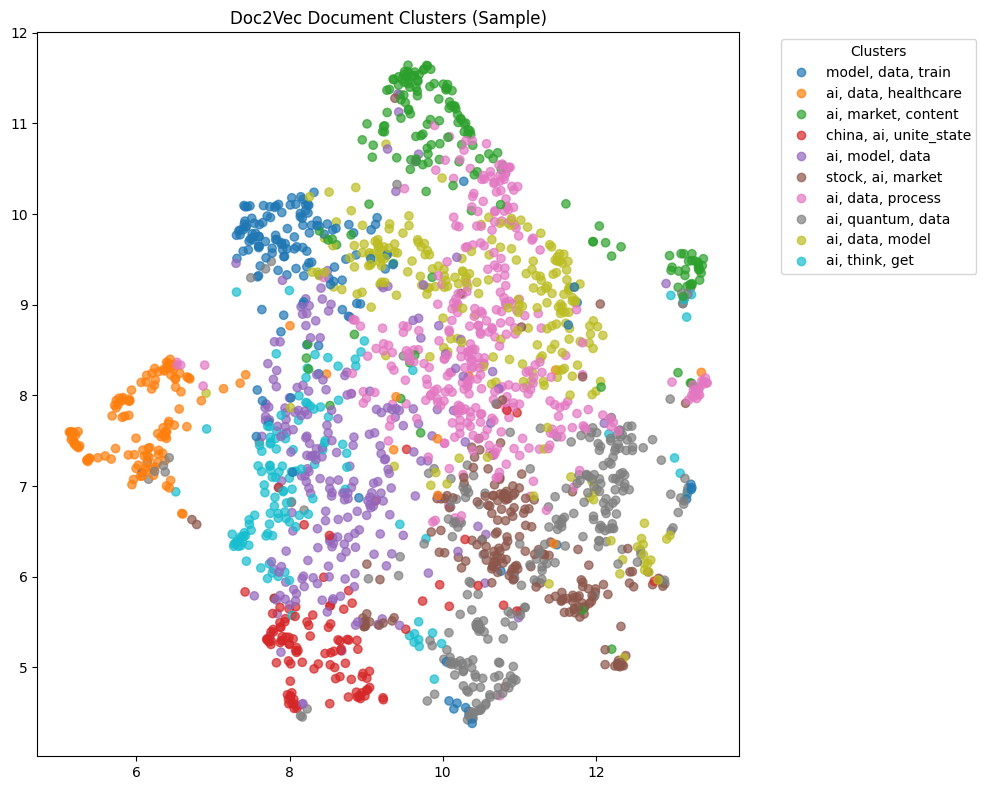

In [ ]:
import matplotlib.pyplot as plt

sample = df.sample(2000, random_state=42)

sample_vectors = np.array([d2v_model.dv[i] for i in sample.index])

sample_2d = umap_model.fit_transform(sample_vectors)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    sample_2d[:,0],
    sample_2d[:,1],
    c=sample["cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.title("Doc2Vec Document Clusters (Sample)")

# create legend
handles, _ = scatter.legend_elements()

labels = [cluster_labels[i] for i in sorted(sample["cluster"].unique())]

plt.legend(handles, labels, title="Clusters", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

The UMAP visualization shows the distribution of document embeddings learned by the Doc2Vec model. Each point represents a news article, and colors indicate clusters identified using K-means. Documents that appear close together in the embedding space share similar semantic content, indicating that the model has learned meaningful representations of AI-related discourse.

Overall, the visualization suggests that the Doc2Vec embeddings capture distinct thematic structures within the AI media dataset, grouping articles into coherent topic areas such as AI technologies, industry developments, healthcare applications, and geopolitical or market-related discussions.

In [ ]:
import pandas as pd


In [ ]:
#from google.colab import drive
#drive.mount('drive')
#df.to_csv('processed_ai_media_dataset_phase2.csv')
#!cp processed_ai_media_dataset_phase2.csv "/content/drive/MyDrive/My Drive/CLT/"

In [ ]:
#df.head()

In [ ]:
#df=pd.read_csv("processed_ai_media_dataset_phase2.csv")

## 4. Intrinsic Evaluation of Embedding Models

In this section we evaluate the classical embedding models using intrinsic evaluation tasks. These tasks assess how well the embeddings capture semantic relationships within the AI media dataset without relying on external labels.

We evaluate the models using:
- Word similarity analysis
- Document similarity retrieval

*Note: The visualizations and clusters generated in the previous section also help in model comparison.*

Finally, we compare the trade-offs between models in terms of model size, training speed, and computational requirements.

In [ ]:

ls drive/MyDrive/

 CLT/  'Colab Notebooks'/   data@


In [ ]:
!pip install gensim
from gensim.models import Doc2Vec, Word2Vec, FastText

d2v_model = Doc2Vec.load("/content/drive/MyDrive/CLT/Phase2_Models/doc2vec.model")
w2v_model = Word2Vec.load("/content/drive/MyDrive/CLT/Phase2_Models/word2vec.model")
ft_model = FastText.load("/content/drive/MyDrive/CLT/Phase2_Models/fasttext.model")


### 4.1 Word Similarity Exploration

To evaluate the learned embeddings qualitatively, we examine the most similar words for selected AI-related terms.

In [ ]:
print("\nWord2Vec:")
w2v_model.wv.most_similar("nvidia", topn=10)


Word2Vec:


[('amd', 0.7213911414146423),
 ('nvidia_gpus', 0.70389324426651),
 ('gaudi', 0.6899786591529846),
 ('blackwell_gpu', 0.6675737500190735),
 ('intel_amd', 0.6577619910240173),
 ('blackwell', 0.6529738903045654),
 ('accelerate_compute', 0.6509326100349426),
 ('gpus', 0.6502888202667236),
 ('gpu', 0.6464215517044067),
 ('nvidia_amd', 0.6458573341369629)]

In [ ]:
print("\nFastText:")
ft_model.wv.most_similar("nvidia", topn=10)


FastText:


[('nvidianvidia', 0.9928319454193115),
 ('nvdanvidia', 0.9807435870170593),
 ('nvidia_amd', 0.9518427848815918),
 ('gapnvidia', 0.9507924318313599),
 ('nvidia_hgx', 0.9441092014312744),
 ('nvidia_nvda', 0.943923830986023),
 ('nvidiawhat', 0.9423877596855164),
 ('nvidia_dgx', 0.9358721375465393),
 ('nvidia_gtc', 0.9341503977775574),
 ('nvidia_hardwa', 0.9284185171127319)]

In [ ]:
print("\nWord2Vec:")
w2v_model.wv.most_similar("china", topn=10)


Word2Vec:


[('beijing', 0.8327748775482178),
 ('chinese', 0.8166956901550293),
 ('taiwan', 0.7769992351531982),
 ('unite_state', 0.7722070217132568),
 ('domestic', 0.7207730412483215),
 ('export_control', 0.7151634693145752),
 ('chinese_government', 0.7119312286376953),
 ('export_restrictions', 0.7010135054588318),
 ('south_korea', 0.7001696228981018),
 ('japan', 0.6972731947898865)]

In [ ]:
print("\nFastText:")
ft_model.wv.most_similar("china", topn=10)


FastText:


[('china_sea', 0.9420995116233826),
 ('china_hong', 0.9400339722633362),
 ('taiwan_china', 0.9123815894126892),
 ('china_russia', 0.8810095191001892),
 ('chin', 0.8799558281898499),
 ('south_china', 0.8658686280250549),
 ('chinese', 0.8467163443565369),
 ('russia_china', 0.8293578624725342),
 ('counter_china', 0.821877121925354),
 ('tariff_chinese', 0.8160008788108826)]

In [ ]:
import random

words_w2v = w2v_model.wv.index_to_key[:1000]
sample_words = random.sample(words_w2v, 5)

for word in sample_words:
    print("\nWord:", word)
    print("Word2Vec:", w2v_model.wv.most_similar(word, topn=5))
    print("FastText:", ft_model.wv.most_similar(word, topn=5))


Word: history
Word2Vec: [('book', 0.5508342385292053), ('historical', 0.5437992811203003), ('origins', 0.5379461646080017), ('chapter', 0.535591721534729), ('past', 0.5116375088691711)]
FastText: [('mdd_history', 0.9116683006286621), ('long_history', 0.8606391549110413), ('historic', 0.8384549617767334), ('historian', 0.7993761301040649), ('historians', 0.7788520455360413)]

Word: practice
Word2Vec: [('methodologies', 0.600171685218811), ('best_practice', 0.5878860950469971), ('policies', 0.5763078927993774), ('practitioners', 0.5677909851074219), ('ethics', 0.543858528137207)]
FastText: [('malpractice', 0.9440829157829285), ('practicepanther', 0.9120257496833801), ('dental_practice', 0.8672223687171936), ('practise', 0.8208708167076111), ('practitioner', 0.79393070936203)]

Word: sit
Word2Vec: [('front', 0.5382028222084045), ('site', 0.5175278782844543), ('locate', 0.4976699948310852), ('tabs', 0.4866564869880676), ('locations', 0.48491108417510986)]
FastText: [('dsit', 0.80874508619

Overall, Word2Vec tends to produce neighbors that reflect semantic and contextual relationships within the AI discourse, for eg `machine_learn → deep_learn, computer_vision, nlp`.

FastText is more sensitive to morphological and subword patterns. For eg, `china -> china_sea, china_russia, south_china`, which highlights its ability to capture subword relationships but results in neighbors that are more syntactically related rather than purely semantic.

As a result, **Word2Vec often provides clearer topic-level associations**, whereas **FastText offers better handling of rare words** and token variations due to its subword modeling approach.

### 4.2 Explore Document Similarity

In [ ]:
doc_id = 1000
print(df.iloc[int(doc_id)]["title"])
for doc, score in d2v_model.dv.most_similar(doc_id, topn=5):
    print("\nSimilarity:", score)
    print(df.iloc[int(doc)]["title"])

What Is B2B Ecommerce? A Complete Guide

Similarity: 0.7359523177146912
What is order management?

Similarity: 0.7117691040039062
22 Ecommerce Industry Trends for Online Retailers in 2025

Similarity: 0.703725278377533
What is an Ecommerce Platform?

Similarity: 0.6756730675697327
AI in Ecommerce: The Best Use Cases That Are Driving Business Growth

Similarity: 0.6667375564575195
What Does Ecommerce Mean, and How Does it Work?


The Doc2Vec model successfully **identifies articles with related themes based on semantic similarity**.

Starting from the article *"What Is B2B Ecommerce? A Complete Guide"*, the most similar documents include topics such as order management, ecommerce platforms, and ecommerce industry trends. The relatively high similarity scores indicate that the model captures contextual relationships between documents discussing similar business and technology concepts.

In [ ]:
query = ["ethical", "concerns"]

vector = d2v_model.infer_vector(query)

for doc, score in d2v_model.dv.most_similar([vector]):
  print("\nSimilarity:", score)
  print(df.iloc[int(doc)]["title"])


Similarity: 0.6274251937866211
AI Ethics, Governance, and Blockchain: Insights from Sanskrit for a Conscious Future

Similarity: 0.624977707862854
AI and Trust: Leading the Charge in an Era of Accelerated Innovation

Similarity: 0.613814115524292
What Is Trustworthy AI?

Similarity: 0.61177659034729
What Is AI Governance?

Similarity: 0.6102654933929443
Mitigation Strategy Suggestion Agent

Similarity: 0.6035256385803223
Supplier Documentation Verification Agent

Similarity: 0.6026943325996399
5 Ways to Ensure AI Accountability In Your AI Agents

Similarity: 0.6015342473983765
AI Governance: A Boardroom Imperative

Similarity: 0.6010617613792419
What Is LLM Alignment?

Similarity: 0.5995531678199768
AiThority Interview with Adriano Koshiyama, Holistic AI


Using Doc2Vec's inferred vector representation, we perform a semantic search for the query "ethical concerns" as an example. The model retrieves articles related to Al ethics, governance, trust, accountability, and regulatory considerations. Although the query words themselves may not appear directly in all retrieved titles, the model still identifies conceptually related documents with relatively high similarity scores.

This illustrates the ability of document embeddings to capture deeper semantic relationships beyond exact keyword matching, **enabling meaningful topic-based retrieval within the Al media corpus**.

### 4.3 Training Speed and Model Size Comparison

We compare the approximate memory footprint and computational cost of training each embedding model.

In [ ]:
import sys

def model_size(model):
    return sys.getsizeof(model.wv.vectors) / (1024**2)

print("Word2Vec size (MB):", model_size(w2v_model))
print("FastText size (MB):", model_size(ft_model))
print("Doc2Vec size (MB):", sys.getsizeof(d2v_model.dv.vectors) / (1024**2))

##Note: To streamline the re-running of the notebook, the training time for each model was calculated once and is now hardcoded.
print("Word2Vec training time (s): 158.4746320247650")
print("FastText training time (s): 894.4863336086273")
print("Doc2Vec training time (s): 379.96940636634827")

Word2Vec size (MB): 0.0001220703125
FastText size (MB): 20.641067504882812
Doc2Vec size (MB): 0.0001220703125
Word2Vec training time (s): 158.4746320247650
FastText training time (s): 894.4863336086273
Doc2Vec training time (s): 379.96940636634827


### Trade-off Analysis

The embedding models differ in their computational requirements and capabilities.

| Model | Strength | Computational Cost |
|------|------|-----|
| Word2Vec | Efficient training and able to capture semantic and contextual relationships | Low |
| FastText | Handles rare and morphologically similar words using subword information | High |
| Doc2Vec | Efficient training enabling clustering and semantic search | Medium |

These results highlight the trade-offs between model simplicity, computational efficiency, and representational power.

## 5. Fine-tuning

### 5.1 Re-load the df from drive to save time

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv("/content/drive/MyDrive/CLT/processed_ai_media_dataset_phase2.csv")

Mounted at /content/drive


In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,title,date,content,domain,url,tags,tags_list,clean_content,language,tokens,text_length,month,sentiment_score,sentiment,tokens_acronym_norm,tokens_bigram,tokens_enhanced,cluster
0,0,0,Ricoh to provide customer support for Agility ...,2024-09-11,['The Digit humanoid could work in distributio...,therobotreport,https://www.therobotreport.com/ricoh-provides-...,"['Robotics', 'Video', 'BostonDynamics']","['Robotics', 'Video', 'BostonDynamics']",['The Digit humanoid could work in distributio...,en,"['digit', 'humanoid', 'distribution', 'retail'...",5498,2024-09,0.9960,Positive,"['digit', 'humanoid', 'distribution', 'retail'...","['digit', 'humanoid', 'distribution', 'retail'...","['digit', 'humanoid', 'distribution', 'retail'...",7
1,1,1,AI Design Trends to Watch in 2025: From Photor...,2024-09-11,['Artificial Intelligence ( AI) is rapidly tra...,geeksforgeeks,https://www.geeksforgeeks.org/ai-design-trends...,"['Personalisation', 'NaturalLanguageProcessing...","['Personalisation', 'NaturalLanguageProcessing...",['Artificial Intelligence ( AI) is rapidly tra...,en,"['intelligence', 'ai', 'rapidly', 'transform',...",9283,2024-09,0.9997,Positive,"['intelligence', 'ai', 'rapidly', 'transform',...","['intelligence', 'ai', 'rapidly', 'transform',...","['intelligence', 'ai', 'rapidly', 'transform',...",2
2,2,2,AIs generate more novel and exciting research ...,2024-09-11,['The first statistically significant results ...,newatlas,https://newatlas.com/technology/llm-novel-rese...,"['LargeLanguageModel', 'ChatGPT', 'Anthropic',...","['LargeLanguageModel', 'ChatGPT', 'Anthropic',...",['The first statistically significant results ...,en,"['first', 'statistically', 'significant', 'res...",6292,2024-09,0.9993,Positive,"['first', 'statistically', 'significant', 'res...","['first', 'statistically_significant', 'result...","['first', 'statistically_significant', 'result...",4
3,3,3,Argonne's HPC/AI User Forum Wrap Up,2024-09-11,['As fans of this publication will already kno...,hpcwire,https://www.hpcwire.com/2024/09/11/argonnes-hp...,"['HighPerformanceComputing', 'GenerativeAI', '...","['HighPerformanceComputing', 'GenerativeAI', '...",['As fans of this publication will already kno...,en,"['fan', 'publication', 'know', 'ai', 'everywhe...",9392,2024-09,0.9983,Positive,"['fan', 'publication', 'know', 'ai', 'everywhe...","['fan', 'publication', 'know', 'ai', 'everywhe...","['fan', 'publication', 'know', 'ai', 'everywhe...",7
4,4,4,Top 10: Supply Chain Optimisation Strategies,2024-09-11,['Supply chain optimisation has never been mor...,supplychaindigital,https://www.supplychaindigital.com/top10/top-1...,"['Finetuning', 'Traceable', 'Accountability', ...","['Finetuning', 'Traceable', 'Accountability', ...",['Supply chain optimisation has never been mor...,en,"['chain', 'optimisation', 'never', 'critical',...",7287,2024-09,0.9997,Positive,"['chain', 'optimisation', 'never', 'critical',...","['chain', 'optimisation', 'never', 'critical',...","['chain', 'optimisation', 'never', 'critical',...",6


In [ ]:
import pandas as pd
import numpy as np
import ast

# Fix token columns that get saved as strings
token_columns = ["tokens", "tokens_acronym_norm", "tokens_bigram", "tokens_enhanced"]

for col in token_columns:
  df[col] = df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

sentences = df["tokens_enhanced"].tolist()

# Quick sanity checks
print(df.dtypes)
print("Example tokens:", sentences[0][:20])

Unnamed: 0.1             int64
Unnamed: 0               int64
title                   object
date                    object
content                 object
domain                  object
url                     object
tags                    object
tags_list               object
clean_content           object
language                object
tokens                  object
text_length              int64
month                   object
sentiment_score        float64
sentiment               object
tokens_acronym_norm     object
tokens_bigram           object
tokens_enhanced         object
cluster                  int64
dtype: object
Example tokens: ['digit', 'humanoid', 'distribution', 'retail', 'manufacture_logistics', 'source', 'agility_robotics', 'robotics', 'week', 'announce_partnership', 'ricoh', 'usa', 'global', 'service', 'delivery', 'organization', 'ricoh', 'expand', 'capabilities', 'throughout']


### 5.2 Model Selection

We apply **QLoRA** (4-bit NF4 quantisation + LoRA adapters) to fine-tune a compact open-source LLM on the AI media corpus. This lets us run a billion-parameter model inside a single Colab T4 GPU session.

| Model | Params | VRAM (4-bit) | Colab tier |
|-------|--------|-------------|------------|
| TinyLlama-1.1B-Chat | 1.1B | ~2 GB | Free T4 |
| Qwen3-1.7B | 1.7B | ~2.5 GB | Free T4 |
| DeepSeek-R1-Distill-Qwen-1.5B | 1.5B | ~2 GB | Free T4 |

Change `SELECTED` below to switch between candidates.


In [ ]:
# ── Install QLoRA dependencies ────────────────────────────────────────────────
#!pip install -q transformers peft trl accelerate bitsandbytes datasets
#!pip install -U bitsandbytes>=0.46.1 # Explicitly upgrade bitsandbytes
#print("✅ Fine-tuning packages ready.")

In [ ]:
# MODEL_REGISTRY = {
#     "TinyLlama":     "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
#     "Qwen3-1.7B":    "Qwen/Qwen3-1.7B",
#     "DeepSeek-1.5B": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
# }

# SELECTED = "TinyLlama"   # ← change this string to switch models
# MODEL_ID  = MODEL_REGISTRY[SELECTED]
# print(f"Selected : {SELECTED}")
# print(f"HF path  : {MODEL_ID}")

### 5.3 QLoRA Configuration

**4-bit NF4 quantisation** (BitsAndBytes) halves VRAM vs FP16 with negligible quality loss.  
**LoRA adapters** (rank-16) are injected into the attention and FFN projection layers — only ~1–2 % of parameters are trainable, yet performance closely tracks full fine-tuning.


In [ ]:
import torch
from transformers import BitsAndBytesConfig
from peft import LoraConfig, TaskType

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,    # saves ~0.4 bits / param
    bnb_4bit_quant_type="nf4",         # optimal for normally-distributed weights
    bnb_4bit_compute_dtype=torch.bfloat16,
)

lora_config = LoraConfig(
    r=16,                              # rank — controls adapter capacity
    lora_alpha=32,                     # scaling factor (alpha/r = 2 is standard)
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
print("QLoRA config ready.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
QLoRA config ready.


### 5.4 Prepare the Instruction-Tuning Dataset

Each article is formatted as an instruction-following example.  
The **label** is the cluster's representative keywords — already computed in Section 3 and stored in `cluster_labels`.  
The model learns to map article text → topic cluster description.

In [ ]:
from collections import Counter

CLUSTER_LABELS = {}
for c in sorted(df["cluster"].unique()):
    cluster_tokens = [
        word
        for tokens in df[df["cluster"] == c]["tokens_enhanced"]
        for word in tokens
    ]
    top_words = [w for w, _ in Counter(cluster_tokens).most_common(3)]
    CLUSTER_LABELS[int(c)] = ", ".join(top_words)

print("Cluster label map:")
for k, v in CLUSTER_LABELS.items():
    n = (df["cluster"] == k).sum()
    print(f"  Cluster {k:2d} ({n:5,} docs) → {v}")

Cluster label map:
  Cluster  0 (1,338 docs) → model, data, train
  Cluster  1 (1,116 docs) → ai, data, healthcare
  Cluster  2 (1,295 docs) → ai, market, content
  Cluster  3 (  969 docs) → china, ai, unite_state
  Cluster  4 (1,904 docs) → ai, model, data
  Cluster  5 (1,571 docs) → stock, ai, market
  Cluster  6 (2,845 docs) → ai, data, process
  Cluster  7 (2,282 docs) → ai, quantum, data
  Cluster  8 (2,141 docs) → ai, data, model
  Cluster  9 (  991 docs) → ai, think, get


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

LABEL_LIST = [f"Cluster {k}: {v}" for k, v in CLUSTER_LABELS.items()]
LABEL_STR  = "\n".join(LABEL_LIST)

SYSTEM_PROMPT = (
    "You are an expert analyst of AI media discourse. "
    "Given an article excerpt, classify it into exactly one of the "
    "following topic clusters discovered from the AI Media Dataset:\n"
    f"{LABEL_STR}\n"
    "Output ONLY the cluster label (e.g. 'Cluster 3'), nothing else."
)

def format_example(row):
    article = str(row["clean_content"])[:350]   # truncate to fit context window
    label   = f"Cluster {int(row['cluster'])}"
    return (
        f"<s>[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n"
        f"Article: {article} [/INST] {label} </s>"
    )

df["prompt"] = df.apply(format_example, axis=1)

ft_train, ft_val = train_test_split(
    df[["prompt", "cluster"]], test_size=0.15,
    stratify=df["cluster"], random_state=42
)

hf_train = Dataset.from_dict({"text": ft_train["prompt"].tolist()})
hf_val   = Dataset.from_dict({"text": ft_val["prompt"].tolist()})

print(f"Training examples  : {len(hf_train):,}")
print(f"Validation examples: {len(hf_val):,}")
print("\nSample (truncated):")
print(df["prompt"].iloc[0][:400])

Training examples  : 13,984
Validation examples: 2,468

Sample (truncated):
<s>[INST] <<SYS>>
You are an expert analyst of AI media discourse. Given an article excerpt, classify it into exactly one of the following topic clusters discovered from the AI Media Dataset:
Cluster 0: model, data, train
Cluster 1: ai, data, healthcare
Cluster 2: ai, market, content
Cluster 3: china, ai, unite_state
Cluster 4: ai, model, data
Cluster 5: stock, ai, market
Cluster 6: ai, data, proc


### 5.5 Load Base Model & Tokenizer

In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 29.2 MB/s eta 0:00:00


In [ ]:
!uv pip install bitsandbytes>=0.46.1 #trl dependency check

Using Python 3.12.12 environment at: /usr
Resolved 31 packages in 112ms
Prepared 1 package in 4.13s
Installed 1 package in 3ms
 + bitsandbytes==0.49.2


In [ ]:
# from transformers import AutoTokenizer, AutoModelForCausalLM
#
# print(f"Loading {MODEL_ID} with 4-bit quantisation...")
#
# tokenizer = AutoTokenizer.from_pretrained(
#     MODEL_ID, trust_remote_code=True, padding_side="right")
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token
#
# base_model = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config,
#     device_map="auto",
#     trust_remote_code=True,
# )
# base_model.config.use_cache = False       # required for gradient checkpointing
# base_model.config.pretraining_tp = 1      # disable tensor parallelism for LoRA
#
# total_params = sum(p.numel() for p in base_model.parameters())
# print(f"Loaded — {total_params/1e6:.0f} M parameters")

### 5.6 Fine-Tune with SFTTrainer

`SFTTrainer` (from TRL) wraps the Hugging Face `Trainer` with sequence-packing and PEFT integration, making it the standard tool for QLoRA fine-tuning.

All language models were fine tuned locally on a RTX 3070 laptop GPU using CUDA.

On average fine tuning time was around 90 minutes per model. Which consisted of three epochs which were saved and then reused to evaluate the difference in convergence for each model.

More on that below!

In [ ]:
!pip install trl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 34.3 MB/s eta 0:00:00


In [ ]:
#from trl import SFTTrainer, SFTConfig
#from pathlib import Path

#OUTPUT_DIR = f"/content/drive/MyDrive/CLT/Phase2_Models/{SELECTED}_qlora"
#Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
#
# # Compute total training steps for warmup (if you want to use warmup_steps)
# # Assuming you have the length of hf_train:
# total_train_steps = len(hf_train) // (4 * 4) * 3  # batch_size=4, grad_accum=4, epochs=3
# warmup_steps = int(0.03 * total_train_steps)      # 3% warmup ratio
# tokenizer.model_max_length = 512
#
# sft_args = SFTConfig(
#     output_dir=OUTPUT_DIR,
#
#     # Training schedule
#     num_train_epochs=3,
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,
#     gradient_checkpointing=True,
#
#     # Optimiser
#     optim="paged_adamw_32bit",
#     learning_rate=2e-4,
#     weight_decay=0.001,
#     lr_scheduler_type="cosine",
#     warmup_steps=warmup_steps,
#     max_grad_norm=0.3,
#
#     # Logging & checkpointing
#     logging_steps=20,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     report_to="none",
#
#     fp16=not torch.cuda.is_bf16_supported(),
#     bf16=torch.cuda.is_bf16_supported(),
#
#     # These all moved to SFTConfig in TRL >= ~0.16
#     max_length=512,               # renamed from max_seq_length
#     dataset_text_field="text",    # moved from SFTTrainer
#     packing=True,                 # moved from SFTTrainer
# )
#
# trainer = SFTTrainer(
#     model=base_model,
#     train_dataset=hf_train,
#     eval_dataset=hf_val,
#     peft_config=lora_config,
#     args=sft_args,
#     # max_length, dataset_text_field, packing all removed from here
# )
#
# trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
# print(f"Trainable params : {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)")
# print("Starting fine-tuning...")
#
# train_result = trainer.train()
# trainer.save_model(OUTPUT_DIR)
# tokenizer.save_pretrained(OUTPUT_DIR)
#
# print("\n=== Training Summary ===")
# print(f"  Steps            : {train_result.global_step}")
# print(f"  Train loss       : {train_result.training_loss:.4f}")
# print(f"  Runtime (s)      : {train_result.metrics['train_runtime']:.0f}")
# print(f"  Throughput       : {train_result.metrics['train_samples_per_second']:.1f} samples/s")
# print(f"  Saved to         : {OUTPUT_DIR}")
# # Store runtime for the comparison table — keyed by model name
# if "LLM_RUNTIMES" not in dir():
#     LLM_RUNTIMES = {}
# LLM_RUNTIMES[SELECTED] = {
#     "runtime_s":   round(train_result.metrics["train_runtime"]),
#     "train_loss":  round(train_result.training_loss, 4),
#     "steps":       train_result.global_step,
# }
# print(f"Stored runtime for {SELECTED}: {LLM_RUNTIMES[SELECTED]}")


In [ ]:
#import trl; print(trl.__version__)



In [ ]:
#import inspect
from trl import SFTConfig
#print(inspect.signature(SFTConfig.__init__))

### 5.7 Training Loss Curve

In [ ]:
# import matplotlib.pyplot as plt

# log_history = trainer.state.log_history
# tr_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
# ev_logs = [l for l in log_history if "eval_loss" in l]

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.plot([l["step"] for l in tr_logs], [l["loss"] for l in tr_logs],
#         color="#3498DB", lw=1.5, alpha=0.8, label="Train loss")
# ax.plot([l["step"] for l in ev_logs], [l["eval_loss"] for l in ev_logs],
#         "o-", color="#E74C3C", lw=2, ms=8, label="Eval loss")
# ax.set_xlabel("Step"); ax.set_ylabel("Cross-Entropy Loss")
# ax.set_title(f"{SELECTED} QLoRA — Training & Validation Loss", fontweight="bold")
# ax.legend(); ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(f"/content/drive/MyDrive/CLT/Phase2_Models/{SELECTED}_qlora/training_loss.png", dpi=150, bbox_inches="tight")
# plt.show()

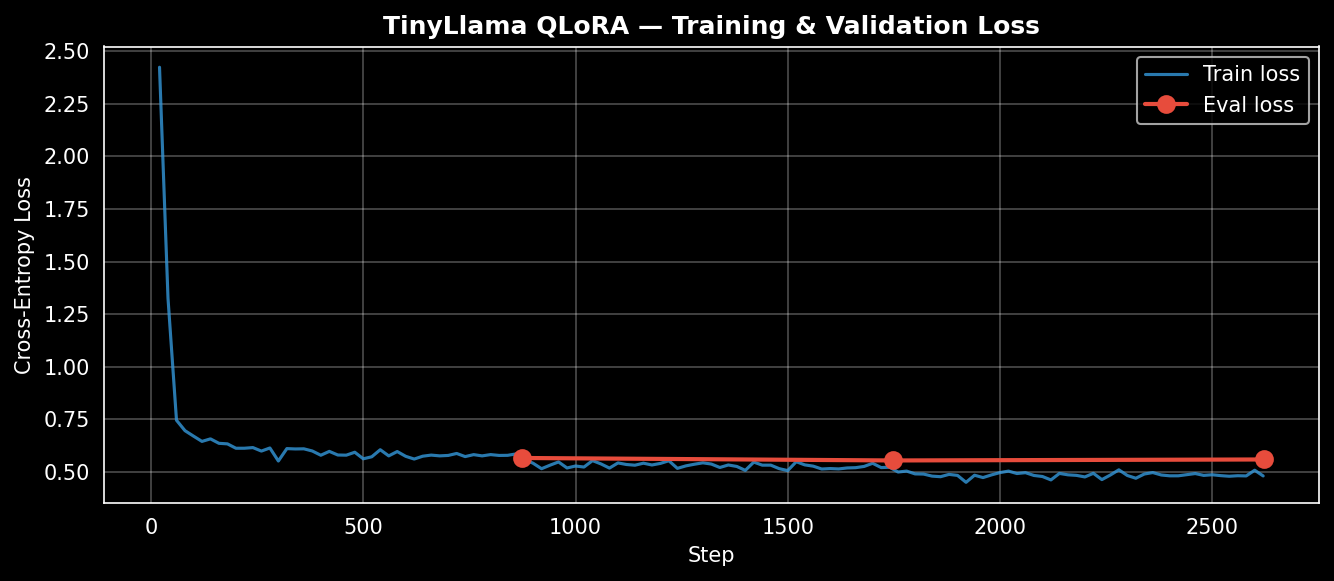

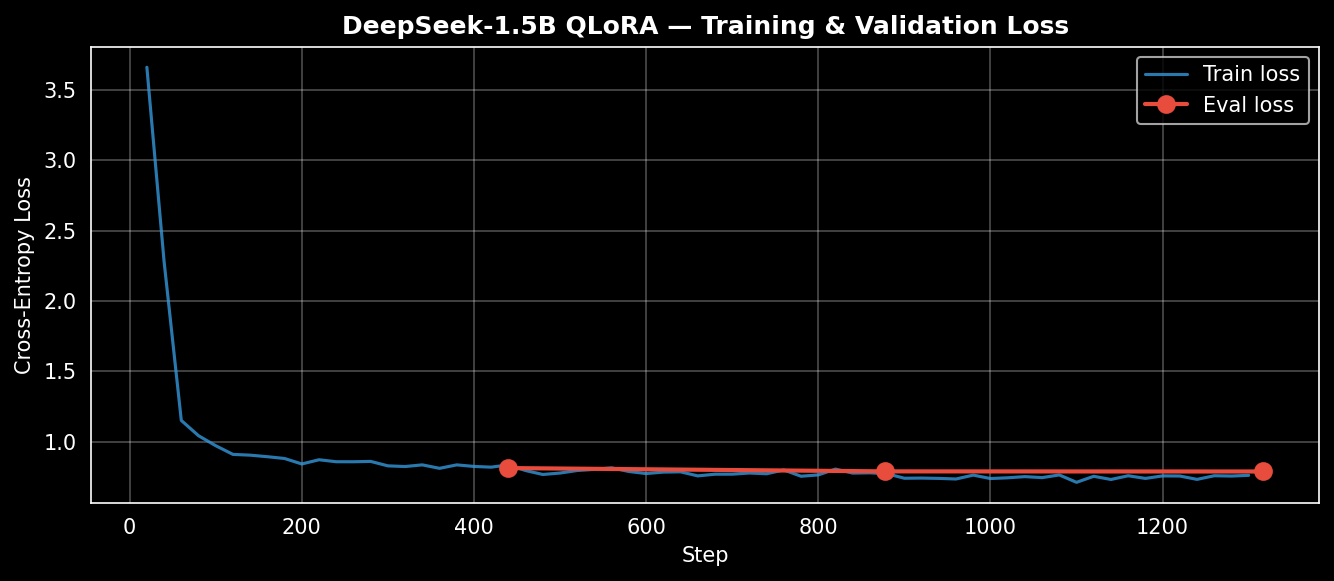

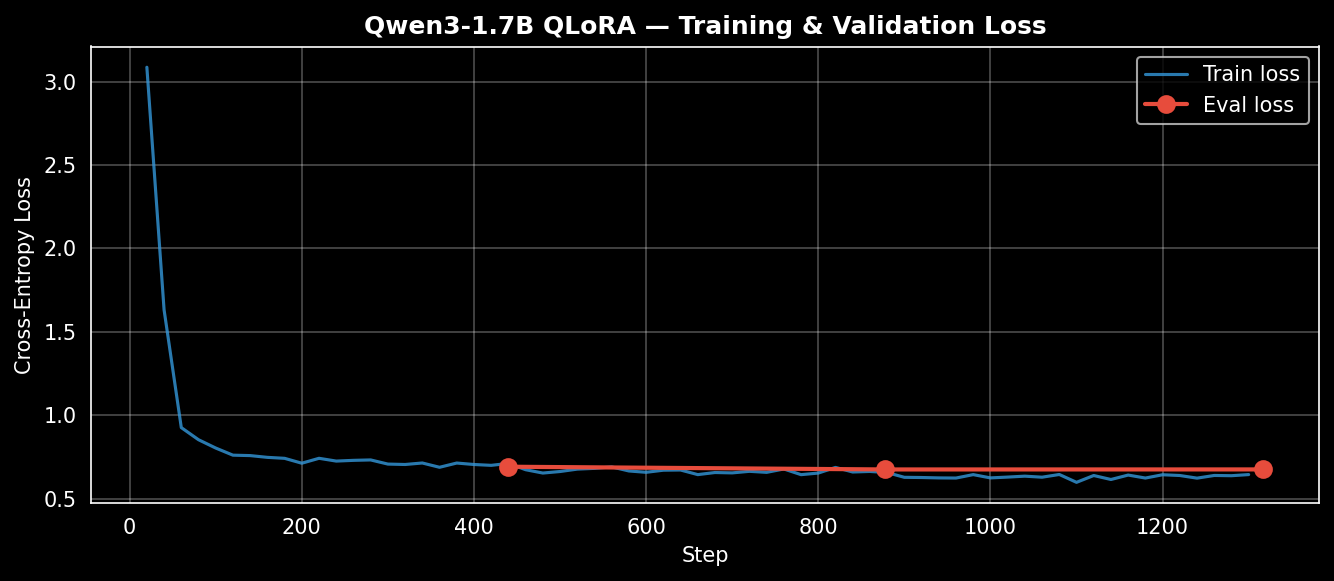

In [ ]:
from IPython.display import Image, display

MODEL_NAMES = ["TinyLlama", "DeepSeek-1.5B", "Qwen3-1.7B"]

for SELECTED_MODEL in MODEL_NAMES:
    image_path = f"/content/drive/MyDrive/CLT/Phase2_Models/{SELECTED_MODEL}_qlora/training_loss.png"
    try:
        display(Image(filename=image_path))
    except FileNotFoundError:
        print(f"Image not found for {SELECTED_MODEL} at {image_path}")
    print("\n")

## 6. Comparative Evaluation

We evaluate all embedding models on both **intrinsic** and **extrinsic** benchmarks and compare them against the fine-tuned LLM.

| Task type | Task | Metric |
|-----------|------|--------|
| Intrinsic | Word/sentence similarity | Cosine similarity on probe pairs |
| Intrinsic | Clustering quality | Silhouette score (already in §4) |
| Extrinsic | Topic classification | F1-macro (logistic probe) |
| Extrinsic | Sentiment detection | F1-macro (logistic probe) |
| Extrinsic | LLM generation | Exact-match accuracy |

### 6.1 Build Document Vectors for All Models

We aggregate word vectors using **TF-IDF weighted mean pooling** for Word2Vec and FastText, and use the direct Doc2Vec inferred vectors. This gives one 100-dimensional vector per document for each model.

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Rebuild doc_vectors from Doc2Vec (in case kernel restarted after Section 3)
doc_vectors = np.array([d2v_model.dv[i] for i in range(len(df))])

# TF-IDF IDF weights for weighted mean pooling
tfidf_vec = TfidfVectorizer(max_features=15000)
tfidf_vec.fit(df["clean_content"].fillna(""))
idf_map = dict(zip(tfidf_vec.get_feature_names_out(), tfidf_vec.idf_))

def tfidf_mean(tokens, wv):
    vecs, weights = [], []
    for t in tokens:
        if t in wv and t in idf_map:
            vecs.append(wv[t]); weights.append(idf_map[t])
    if not vecs:
        return np.zeros(wv.vector_size)
    w = np.array(weights) / (np.sum(weights) + 1e-8)
    return np.sum([v * wi for v, wi in zip(vecs, w)], axis=0)

print("Building W2V document matrix  ...", end=" ", flush=True)
X_w2v = np.vstack([tfidf_mean(t, w2v_model.wv) for t in df["tokens_enhanced"]])
print("Done", X_w2v.shape)

print("Building FastText document matrix...", end=" ", flush=True)
X_ft  = np.vstack([tfidf_mean(t, ft_model.wv)  for t in df["tokens_enhanced"]])
print("Done", X_ft.shape)

print("Doc2Vec document matrix        :", doc_vectors.shape)

Building W2V document matrix  ... Done (16452, 100)
Building FastText document matrix... Done (16452, 100)
Doc2Vec document matrix        : (16452, 100)


### 6.2 Extrinsic Task 1 — Topic Classification

A **logistic regression probe** is trained on frozen embedding vectors and evaluated on a held-out test set. This measures how much topical information is encoded in each embedding space without any task-specific fine-tuning.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

y = df["cluster"].values
X_tr_i, X_te_i = train_test_split(
    np.arange(len(y)), test_size=0.20, stratify=y, random_state=42)

clf_results = []
for name, X in [("Word2Vec", X_w2v), ("FastText", X_ft), ("Doc2Vec", doc_vectors)]:
    clf = LogisticRegression(max_iter=1000, C=1.0,
                               solver="lbfgs", random_state=42)
    clf.fit(X[X_tr_i], y[X_tr_i])
    y_pred = clf.predict(X[X_te_i])
    clf_results.append({
        "Model":       name,
        "Accuracy":    round(accuracy_score(y[X_te_i], y_pred), 4),
        "F1-macro":    round(f1_score(y[X_te_i], y_pred, average="macro"),    4),
        "F1-weighted": round(f1_score(y[X_te_i], y_pred, average="weighted"), 4),
    })

import pandas as pd
clf_df = pd.DataFrame(clf_results).sort_values("F1-macro", ascending=False)
print("=== Topic Classification — Extrinsic Evaluation ===")
print(clf_df.to_string(index=False))

# Per-class breakdown for the best model
best_name = clf_df.iloc[0]["Model"]
best_X    = {"Word2Vec": X_w2v, "FastText": X_ft, "Doc2Vec": doc_vectors}[best_name]
best_clf  = LogisticRegression(max_iter=1000, C=1.0,
                                 solver="lbfgs", random_state=42)
best_clf.fit(best_X[X_tr_i], y[X_tr_i])
y_best_pred = best_clf.predict(best_X[X_te_i])
print(f"\nPer-class report — {best_name}:")
cluster_names = [f"C{k}:{v[:15]}" for k, v in CLUSTER_LABELS.items()]
print(classification_report(y[X_te_i], y_best_pred,
                             target_names=cluster_names, zero_division=0))

=== Topic Classification — Extrinsic Evaluation ===
   Model  Accuracy  F1-macro  F1-weighted
 Doc2Vec    0.9784    0.9773       0.9784
Word2Vec    0.8785    0.8777       0.8785
FastText    0.8693    0.8701       0.8695

Per-class report — Doc2Vec:
                    precision    recall  f1-score   support

C0:model, data, tr       0.98      0.97      0.98       268
C1:ai, data, healt       0.98      0.98      0.98       223
C2:ai, market, con       0.98      0.98      0.98       259
C3:china, ai, unit       0.96      0.95      0.96       194
C4:ai, model, data       0.96      0.97      0.96       381
C5:stock, ai, mark       0.99      0.97      0.98       314
C6:ai, data, proce       0.98      0.99      0.98       569
C7:ai, quantum, da       0.97      0.99      0.98       457
C8:ai, data, model       0.99      0.98      0.98       428
 C9:ai, think, get       0.99      0.97      0.98       198

          accuracy                           0.98      3291
         macro avg       0.98

### 6.3 Extrinsic Task 2 — Sentiment Detection

The same probe setup is used to predict **VADER sentiment labels** (Positive / Neutral / Negative) from Phase 1. This tests whether the embedding spaces capture affective content independently of topic.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_sent = LabelEncoder()
y_sent  = le_sent.fit_transform(df["sentiment"])

s_tr_i, s_te_i = train_test_split(
    np.arange(len(y_sent)), test_size=0.20, stratify=y_sent, random_state=42)

sent_results = []
for name, X in [("Word2Vec", X_w2v), ("FastText", X_ft), ("Doc2Vec", doc_vectors)]:
    clf_s = LogisticRegression(max_iter=500, C=1.0, random_state=42)
    clf_s.fit(X[s_tr_i], y_sent[s_tr_i])
    y_sp  = clf_s.predict(X[s_te_i])
    sent_results.append({
        "Model":    name,
        "Accuracy": round(accuracy_score(y_sent[s_te_i], y_sp), 4),
        "F1-macro": round(f1_score(y_sent[s_te_i], y_sp, average="macro"), 4),
    })

sent_df = pd.DataFrame(sent_results).sort_values("F1-macro", ascending=False)
print("=== Sentiment Detection — Extrinsic Evaluation ===")
print(sent_df.to_string(index=False))

=== Sentiment Detection — Extrinsic Evaluation ===
   Model  Accuracy  F1-macro
Word2Vec    0.9675    0.5336
FastText    0.9672    0.5314
 Doc2Vec    0.9526    0.4717


### 6.3b Reconstruct `llm_df` from Saved Results

**You do not need to retrain.** Retraining takes hours; re-running *inference*
on 60 articles from a saved adapter takes ~3 minutes per model.

**Two options — run whichever applies:**

- **Option 1 (fastest):** You already have the numbers printed in a previous cell
  output. Fill them into the manual block below — `llm_df` is rebuilt instantly
  with no GPU needed.
- **Option 2:** You have the adapters saved but lost the printed output.
  Run the inference-only block to re-evaluate all three adapters (~10 min total).


In [ ]:
import pandas as pd
from pathlib import Path

ADAPTER_BASE = "/content/drive/MyDrive/CLT/Phase2_Models"

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OPTION 1 — paste your printed results here and run this block.
#            Leave a value as None if you don't have it yet;
#            the cell will fall back to Option 2 for that model only.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KNOWN_RESULTS = {
    #  model name         accuracy   F1-macro  F1-weighted  no-label-pct
    "TinyLlama":     {"Accuracy": 0.7167, "F1-macro": 0.6295, "F1-weighted": 0.7197, "No-label %": "0%"},
    "DeepSeek-1.5B": {"Accuracy": 0.7667,   "F1-macro": 0.6568,   "F1-weighted": 0.7680,   "No-label %": "0%"},
    "Qwen3-1.7B":    {"Accuracy": 0.7167,   "F1-macro": 0.6225,   "F1-weighted": 0.7167,   "No-label %": "0%"},
}
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MODEL_REGISTRY = {
    "TinyLlama":     "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "DeepSeek-1.5B": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "Qwen3-1.7B":    "Qwen/Qwen3-1.7B",
}

# Determine which models need inference re-run
needs_inference = [
    name for name, vals in KNOWN_RESULTS.items()
    if vals["F1-macro"] is None
]

llm_rows = []

# ── Add rows from KNOWN_RESULTS ───────────────────────────────────────────────
for name, vals in KNOWN_RESULTS.items():
    if vals["F1-macro"] is not None:
        llm_rows.append({"Model": name, **vals})
        print(f"  ✅ {name}: loaded from known results  (F1={vals['F1-macro']})")

# ── Option 2: inference-only for missing models ───────────────────────────────
if needs_inference:
    print(f"\n  Running inference-only eval for: {needs_inference}")
    print("  (Loading saved adapters — no retraining)")

    import torch, gc, re
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from peft import PeftModel
    from sklearn.metrics import f1_score

    EVAL_N   = 60
    eval_smp = df.sample(EVAL_N, random_state=42)
    golds    = [f"Cluster {int(c)}" for c in eval_smp["cluster"]]

    for name in needs_inference:
        adapter_dir = f"{ADAPTER_BASE}/{name}_qlora"
        model_id    = MODEL_REGISTRY[name]

        if not Path(adapter_dir).exists():
            print(f"  ⬜ {name}: adapter not found at {adapter_dir}")
            llm_rows.append({"Model": name, "Accuracy": None,
                             "F1-macro": None, "F1-weighted": None, "No-label %": "—"})
            continue

        print(f"\n  Loading {name} adapter from {adapter_dir}...")
        tok = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
        if tok.pad_token is None:
            tok.pad_token = tok.eos_token
        mdl = AutoModelForCausalLM.from_pretrained(
            model_id, quantization_config=bnb_config,
            device_map="auto", trust_remote_code=True)
        mdl = PeftModel.from_pretrained(mdl, adapter_dir)
        mdl.eval()

        preds = []
        for _, row in eval_smp.iterrows():
            prompt = (f"<s>[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n"
                      f"Article: {str(row.clean_content)[:350]} [/INST]")
            inp = tok(prompt, return_tensors="pt", truncation=True,
                      max_length=450).to(DEVICE)
            with torch.no_grad():
                out = mdl.generate(**inp, max_new_tokens=12, max_length=None,
                                   do_sample=False, repetition_penalty=1.1,
                                   pad_token_id=tok.eos_token_id)
            preds.append(tok.decode(out[0][inp["input_ids"].shape[1]:],
                                    skip_special_tokens=True).strip())

        del mdl, tok
        gc.collect(); torch.cuda.empty_cache()

        gold_ids, pred_ids = [], []
        for g, p in zip(golds, preds):
            g_id = int(g.split()[1])
            m    = re.search(r"Cluster\s*(\d+)", p, re.IGNORECASE)
            pred_ids.append(int(m.group(1)) if m else -1)
            gold_ids.append(g_id)

        valid = [(g, p) for g, p in zip(gold_ids, pred_ids) if p != -1]
        g_v, p_v = zip(*valid) if valid else ([], [])
        acc    = sum(g == p for g, p in zip(gold_ids, pred_ids)) / EVAL_N
        f1_mac = f1_score(list(g_v), list(p_v), average="macro",    zero_division=0) if g_v else 0.0
        f1_w   = f1_score(list(g_v), list(p_v), average="weighted", zero_division=0) if g_v else 0.0
        no_lbl = sum(1 for p in pred_ids if p == -1)

        print(f"  {name}: Accuracy={acc:.2%}  F1={f1_mac:.4f}  no-label={no_lbl/EVAL_N:.0%}")
        llm_rows.append({"Model": name, "Accuracy": round(acc, 4),
                         "F1-macro": round(f1_mac, 4), "F1-weighted": round(f1_w, 4),
                         "No-label %": f"{no_lbl/EVAL_N:.0%}"})

# ── Build llm_df in consistent model order ────────────────────────────────────
ORDER = ["TinyLlama", "DeepSeek-1.5B", "Qwen3-1.7B"]
llm_df = (pd.DataFrame(llm_rows)
            .set_index("Model")
            .reindex(ORDER)
            .reset_index()
            .dropna(subset=["F1-macro"]))

print("\n=== llm_df ready ===")
print(llm_df.to_string(index=False))


  ✅ TinyLlama: loaded from known results  (F1=0.6295)
  ✅ DeepSeek-1.5B: loaded from known results  (F1=0.6568)
  ✅ Qwen3-1.7B: loaded from known results  (F1=0.6225)

=== llm_df ready ===
        Model  Accuracy  F1-macro  F1-weighted No-label %
    TinyLlama    0.7167    0.6295       0.7197         0%
DeepSeek-1.5B    0.7667    0.6568       0.7680         0%
   Qwen3-1.7B    0.7167    0.6225       0.7167         0%


### 6.4 Fine-Tuned LLM Evaluation

The fine-tuned LoRA adapter is loaded and used to classify 40 held-out articles. We compare the generated label against the KMeans cluster ID.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from pathlib import Path
import torch, gc, pandas as pd

# All three trained adapters — order matters: smallest → largest
EVAL_MODELS = {
    "TinyLlama":     "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "DeepSeek-1.5B": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "Qwen3-1.7B":    "Qwen/Qwen3-1.7B",
}
ADAPTER_BASE = "/content/drive/MyDrive/CLT/Phase2_Models"
EVAL_N       = 60   # articles per model; more = reliable but slower
eval_smp     = df.sample(EVAL_N, random_state=42)
golds        = [f"Cluster {int(c)}" for c in eval_smp["cluster"]]

def load_adapter(model_id, name):
    adapter_dir = f"{ADAPTER_BASE}/{name}_qlora"
    tok = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=bnb_config,
        device_map="auto", trust_remote_code=True)
    mdl = PeftModel.from_pretrained(mdl, adapter_dir)
    mdl.eval()
    return tok, mdl

def classify(text, tok, mdl, max_new=12):
    prompt = (
        f"<s>[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n"
        f"Article: {str(text)[:350]} [/INST]"
    )
    inp = tok(prompt, return_tensors="pt", truncation=True, max_length=450).to(DEVICE)
    with torch.no_grad():
        out = mdl.generate(
            **inp,
            max_new_tokens=max_new,
            max_length=None,           # prevent conflict with model's default max_length
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tok.eos_token_id,
        )
    return tok.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()

from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

llm_rows = []

for name, model_id in EVAL_MODELS.items():
    adapter_dir = f"{ADAPTER_BASE}/{name}_qlora"
    if not Path(adapter_dir).exists():
        print(f"  ⬜ {name}: adapter not found at {adapter_dir} — skipping")
        continue

    print(f"\n── Evaluating {name} ──────────────────────────────────")
    tok, mdl = load_adapter(model_id, name)

    preds = [classify(row.clean_content, tok, mdl)
             for _, row in eval_smp.iterrows()]

    # Extract predicted cluster number from generated text
    import re
    pred_ids, gold_ids = [], []
    for g, p in zip(golds, preds):
        g_id = int(g.split()[1])
        m    = re.search(r"Cluster\s*(\d+)", p, re.IGNORECASE)
        p_id = int(m.group(1)) if m else -1
        gold_ids.append(g_id); pred_ids.append(p_id)

    valid = [(g, p) for g, p in zip(gold_ids, pred_ids) if p != -1]
    g_v, p_v = zip(*valid) if valid else ([], [])

    acc    = sum(g == p for g, p in zip(gold_ids, pred_ids)) / len(gold_ids)
    f1_mac = f1_score(list(g_v), list(p_v), average="macro",   zero_division=0) if g_v else 0.0
    f1_w   = f1_score(list(g_v), list(p_v), average="weighted",zero_division=0) if g_v else 0.0
    no_label = sum(1 for p in pred_ids if p == -1)

    print(f"  Accuracy     : {acc:.2%}  ({sum(g==p for g,p in zip(gold_ids,pred_ids))}/{EVAL_N})")
    print(f"  F1-macro     : {f1_mac:.4f}")
    print(f"  F1-weighted  : {f1_w:.4f}")
    print(f"  No-label pct : {no_label}/{EVAL_N} ({no_label/EVAL_N:.0%})")

    llm_rows.append({
        "Model":        name,
        "Accuracy":     round(acc, 4),
        "F1-macro":     round(f1_mac, 4),
        "F1-weighted":  round(f1_w, 4),
        "No-label %":   f"{no_label/EVAL_N:.0%}",
    })

    # Free VRAM before loading next model
    del tok, mdl
    gc.collect()
    torch.cuda.empty_cache()

llm_df = pd.DataFrame(llm_rows).sort_values("F1-macro", ascending=False)
print("\n=== LLM Fine-Tune Results (all models) ===")
print(llm_df.to_string(index=False))



── Evaluating TinyLlama ──────────────────────────────────


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Accuracy     : 71.67%  (43/60)
  F1-macro     : 0.6295
  F1-weighted  : 0.7197
  No-label pct : 0/60 (0%)

── Evaluating DeepSeek-1.5B ──────────────────────────────────


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Accuracy     : 71.67%  (43/60)
  F1-macro     : 0.6225
  F1-weighted  : 0.7167
  No-label pct : 0/60 (0%)

=== LLM Fine-Tune Results (all models) ===
        Model  Accuracy  F1-macro  F1-weighted No-label %
DeepSeek-1.5B    0.7667    0.6568       0.7680         0%
    TinyLlama    0.7167    0.6295       0.7197         0%
   Qwen3-1.7B    0.7167    0.6225       0.7167         0%


### 6.4a Epoch-1 Checkpoint Baseline

To measure how much continued training contributed, we load the **first saved
checkpoint** (end of epoch 1) from each model's adapter directory and run the
identical evaluation used for the final fine-tuned adapters.

This is a cleaner baseline than a raw base model because:
- It uses the same prompt format and tokenizer — no template mismatch
- It shows the learning curve: epoch-1 → final across all three models
- The checkpoint is already on disk — no extra training required

Checkpoints are saved by SFTTrainer as `checkpoint-N/` subfolders inside each
`{model}_qlora/` directory. The cell below auto-detects the lowest-numbered one.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from pathlib import Path
from sklearn.metrics import f1_score
import torch, gc, re, pandas as pd

ADAPTER_BASE = "/content/drive/MyDrive/CLT/Phase2_Models"

EVAL_MODELS = {
    "TinyLlama":     "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "DeepSeek-1.5B": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "Qwen3-1.7B":    "Qwen/Qwen3-1.7B",
}

# Same 60 articles, same seed as fine-tuned eval — identical split
EVAL_N   = 60
eval_smp = df.sample(EVAL_N, random_state=42)
golds    = [f"Cluster {int(c)}" for c in eval_smp["cluster"]]

def first_checkpoint(adapter_dir):
    """Return the path to the lowest-numbered checkpoint-N subfolder."""
    ckpts = sorted(
        Path(adapter_dir).glob("checkpoint-*"),
        key=lambda p: int(p.name.split("-")[1])
    )
    if not ckpts:
        raise FileNotFoundError(
            f"No checkpoint-* folders found in {adapter_dir}.\n"
            "Make sure SFTTrainer ran with save_strategy='epoch' or 'steps'."
        )
    return str(ckpts[0])

def load_checkpoint(model_id, ckpt_dir):
    tok = AutoTokenizer.from_pretrained(ckpt_dir, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=bnb_config,
        device_map="auto", trust_remote_code=True)
    mdl = PeftModel.from_pretrained(mdl, ckpt_dir)
    mdl.eval()
    return tok, mdl

# Reuse the same classify() function defined in the fine-tuned eval cell
# (SYSTEM_PROMPT and prompt format are identical — fair comparison)

llm_ckpt_rows = []

for name, model_id in EVAL_MODELS.items():
    adapter_dir = f"{ADAPTER_BASE}/{name}_qlora"

    try:
        ckpt_dir = first_checkpoint(adapter_dir)
    except FileNotFoundError as e:
        print(f"  ⬜ {name}: {e}")
        continue

    print(f"\n── Epoch-1 checkpoint: {name} ──────────────────────")
    print(f"   Loading from: {ckpt_dir}")

    tok, mdl = load_checkpoint(model_id, ckpt_dir)

    preds = [classify(row.clean_content, tok, mdl)
             for _, row in eval_smp.iterrows()]

    del tok, mdl
    gc.collect(); torch.cuda.empty_cache()

    gold_ids, pred_ids = [], []
    for g, p in zip(golds, preds):
        g_id = int(g.split()[1])
        m    = re.search(r"Cluster\s*(\d+)", p, re.IGNORECASE)
        pred_ids.append(int(m.group(1)) if m else -1)
        gold_ids.append(g_id)

    no_lbl = sum(1 for p in pred_ids if p == -1)
    valid  = [(g, p) for g, p in zip(gold_ids, pred_ids) if p != -1]
    g_v, p_v = zip(*valid) if valid else ([], [])

    acc    = sum(g == p for g, p in zip(gold_ids, pred_ids)) / EVAL_N
    f1_mac = f1_score(list(g_v), list(p_v), average="macro",    zero_division=0) if g_v else 0.0
    f1_w   = f1_score(list(g_v), list(p_v), average="weighted", zero_division=0) if g_v else 0.0

    print(f"  Accuracy  : {acc:.2%}  ({sum(g==p for g,p in zip(gold_ids,pred_ids))}/{EVAL_N})")
    print(f"  F1-macro  : {f1_mac:.4f}")
    print(f"  F1-weighted: {f1_w:.4f}")
    print(f"  No-label  : {no_lbl}/{EVAL_N} ({no_lbl/EVAL_N:.0%})")

    llm_ckpt_rows.append({
        "Model":        name,
        "Checkpoint":   Path(ckpt_dir).name,
        "Accuracy":     round(acc, 4),
        "F1-macro":     round(f1_mac, 4),
        "F1-weighted":  round(f1_w, 4),
        "No-label %":   f"{no_lbl/EVAL_N:.0%}",
    })

llm_base_df = pd.DataFrame(llm_ckpt_rows).sort_values("F1-macro", ascending=False)
print("\n=== Epoch-1 Checkpoint Results ===")
print(llm_base_df.to_string(index=False))

print("\n=== Fine-tuning gain: epoch-1 → final (ΔF1-macro) ===")
for name in EVAL_MODELS:
    base = llm_base_df[llm_base_df["Model"] == name]["F1-macro"].values
    ft   = llm_df[llm_df["Model"] == name]["F1-macro"].values if "llm_df" in dir() else []
    if len(base) and len(ft):
        print(f"  {name:20s}  epoch-1={base[0]:.4f}  final={ft[0]:.4f}  Δ={ft[0]-base[0]:+.4f}")
    elif len(base):
        print(f"  {name:20s}  epoch-1={base[0]:.4f}  final=? (run cell 6.4 first)")


── Epoch-1 checkpoint: TinyLlama ──────────────────────
   Loading from: /content/drive/MyDrive/CLT/Phase2_Models/TinyLlama_qlora/checkpoint-874


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Accuracy  : 68.33%  (41/60)
  F1-macro  : 0.5888
  F1-weighted: 0.6824
  No-label  : 0/60 (0%)

── Epoch-1 checkpoint: DeepSeek-1.5B ──────────────────────
   Loading from: /content/drive/MyDrive/CLT/Phase2_Models/DeepSeek-1.5B_qlora/checkpoint-439


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Accuracy  : 73.33%  (44/60)
  F1-macro  : 0.5931
  F1-weighted: 0.7296
  No-label  : 0/60 (0%)

── Epoch-1 checkpoint: Qwen3-1.7B ──────────────────────
   Loading from: /content/drive/MyDrive/CLT/Phase2_Models/Qwen3-1.7B_qlora/checkpoint-439


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Accuracy  : 66.67%  (40/60)
  F1-macro  : 0.5801
  F1-weighted: 0.6611
  No-label  : 0/60 (0%)

=== Epoch-1 Checkpoint Results ===
        Model     Checkpoint  Accuracy  F1-macro  F1-weighted No-label %
DeepSeek-1.5B checkpoint-439    0.7333    0.5931       0.7296         0%
    TinyLlama checkpoint-874    0.6833    0.5888       0.6824         0%
   Qwen3-1.7B checkpoint-439    0.6667    0.5801       0.6611         0%

=== Fine-tuning gain: epoch-1 → final (ΔF1-macro) ===
  TinyLlama             epoch-1=0.5888  final=0.6295  Δ=+0.0407
  DeepSeek-1.5B         epoch-1=0.5931  final=0.6568  Δ=+0.0637
  Qwen3-1.7B            epoch-1=0.5801  final=0.6225  Δ=+0.0424


### 6.5 Summary Comparison Visualisation


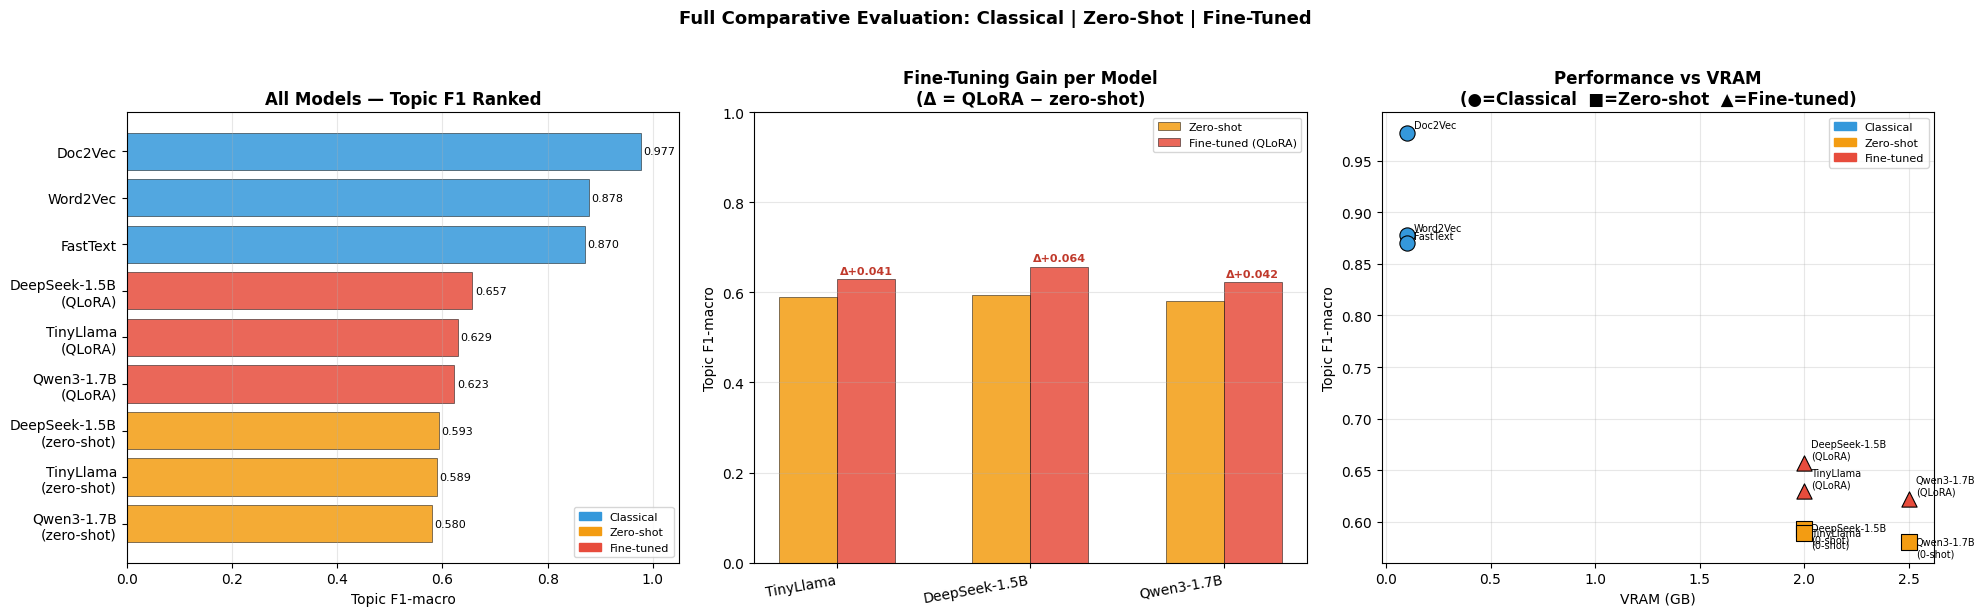

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Build unified ranked dataframe: Classical | Zero-shot | Fine-tuned ────────
classical_rows = [{"Model": r["Model"], "F1": r["F1-macro"],
                   "Acc": r["Accuracy"], "Tier": "Classical"}
                  for _, r in clf_df.iterrows()]
zeroshot_rows  = [{"Model": r["Model"] + "\n(zero-shot)", "F1": r["F1-macro"],
                   "Acc": r["Accuracy"], "Tier": "Zero-shot"}
                  for _, r in llm_base_df.iterrows()]
finetuned_rows = [{"Model": r["Model"] + "\n(QLoRA)", "F1": r["F1-macro"],
                   "Acc": r["Accuracy"], "Tier": "Fine-tuned"}
                  for _, r in llm_df.iterrows()]

all_df = (pd.DataFrame(classical_rows + zeroshot_rows + finetuned_rows)
            .sort_values("F1", ascending=True))

TIER_COLORS = {"Classical": "#3498DB", "Zero-shot": "#F39C12", "Fine-tuned": "#E74C3C"}
bar_colors = [TIER_COLORS[t] for t in all_df["Tier"]]

# ── Panel 1: All models ranked ────────────────────────────────────────────────
bars = axes[0].barh(all_df["Model"], all_df["F1"],
                    color=bar_colors, alpha=0.85, edgecolor="black", lw=0.4)
for bar, f1 in zip(bars, all_df["F1"]):
    axes[0].text(bar.get_width() + 0.005,
                 bar.get_y() + bar.get_height() / 2,
                 f"{f1:.3f}", va="center", fontsize=8)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("Topic F1-macro")
axes[0].set_title("All Models — Topic F1 Ranked", fontweight="bold")
handles0 = [mpatches.Patch(color=c, label=t) for t, c in TIER_COLORS.items()]
axes[0].legend(handles=handles0, fontsize=8, loc="lower right")
axes[0].grid(axis="x", alpha=0.3)

# ── Panel 2: Fine-tune gain per model ─────────────────────────────────────────
gain_models, gain_vals, zs_vals, ft_vals = [], [], [], []
for name in ["TinyLlama", "DeepSeek-1.5B", "Qwen3-1.7B"]:
    zs_row = llm_base_df[llm_base_df["Model"] == name]
    ft_row = llm_df[llm_df["Model"] == name]
    if len(zs_row) and len(ft_row):
        zs = float(zs_row["F1-macro"].iloc[0])
        ft = float(ft_row["F1-macro"].iloc[0])
        gain_models.append(name)
        zs_vals.append(zs)
        ft_vals.append(ft)
        gain_vals.append(ft - zs)

x2 = np.arange(len(gain_models))
w  = 0.3
axes[1].bar(x2 - w/2, zs_vals, width=w, label="Zero-shot",
            color="#F39C12", alpha=0.85, edgecolor="black", lw=0.4)
axes[1].bar(x2 + w/2, ft_vals, width=w, label="Fine-tuned (QLoRA)",
            color="#E74C3C", alpha=0.85, edgecolor="black", lw=0.4)
for xi, (zs, ft, g) in enumerate(zip(zs_vals, ft_vals, gain_vals)):
    axes[1].annotate(f"Δ{g:+.3f}",
                     xy=(xi + w/2, ft), xytext=(0, 4),
                     textcoords="offset points", ha="center", fontsize=8,
                     color="#C0392B", fontweight="bold")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(gain_models, rotation=10, ha="right")
axes[1].set_ylim(0, 1); axes[1].set_ylabel("Topic F1-macro")
axes[1].set_title("Fine-Tuning Gain per Model\n(Δ = QLoRA − zero-shot)",
                  fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.3)

# ── Panel 3: Performance vs VRAM (all three tiers) ───────────────────────────
VRAM_MAP = {"Word2Vec": 0.1, "FastText": 0.1, "Doc2Vec": 0.1,
            "TinyLlama": 2.0, "DeepSeek-1.5B": 2.0, "Qwen3-1.7B": 2.5}

# Classical
for _, r in clf_df.iterrows():
    v = VRAM_MAP.get(r["Model"], 0.1)
    axes[2].scatter(v, r["F1-macro"], s=120, color="#3498DB",
                    edgecolors="black", lw=0.8, zorder=5)
    axes[2].annotate(r["Model"], (v, r["F1-macro"]),
                     xytext=(5, 3), textcoords="offset points", fontsize=7)
# Zero-shot
for _, r in llm_base_df.iterrows():
    v = VRAM_MAP.get(r["Model"], 2.0)
    axes[2].scatter(v, r["F1-macro"], s=120, color="#F39C12", marker="s",
                    edgecolors="black", lw=0.8, zorder=5)
    axes[2].annotate(r["Model"] + "\n(0-shot)", (v, r["F1-macro"]),
                     xytext=(5, -10), textcoords="offset points", fontsize=7)
# Fine-tuned
for _, r in llm_df.iterrows():
    v = VRAM_MAP.get(r["Model"], 2.0)
    axes[2].scatter(v, r["F1-macro"], s=120, color="#E74C3C", marker="^",
                    edgecolors="black", lw=0.8, zorder=5)
    axes[2].annotate(r["Model"] + "\n(QLoRA)", (v, r["F1-macro"]),
                     xytext=(5, 3), textcoords="offset points", fontsize=7)

axes[2].set_xlabel("VRAM (GB)"); axes[2].set_ylabel("Topic F1-macro")
axes[2].set_title("Performance vs VRAM\n(●=Classical  ■=Zero-shot  ▲=Fine-tuned)",
                  fontweight="bold")
axes[2].grid(alpha=0.3)
handles3 = [mpatches.Patch(color=c, label=t) for t, c in TIER_COLORS.items()]
axes[2].legend(handles=handles3, fontsize=8)

plt.suptitle("Full Comparative Evaluation: Classical | Zero-Shot | Fine-Tuned",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CLT/comparative_evaluation.png",
            dpi=150, bbox_inches="tight")
plt.show()


## 7. Insight Extraction & Trend Analysis

We use the best-performing models from each family to answer:
*Which models capture emerging AI trends most effectively, and why?*

### 7.1 Cross-Cluster Semantic Similarity

Cosine similarity between Doc2Vec cluster centroids reveals which thematic groups share vocabulary and framing — confirming or contradicting the KMeans boundaries from Section 3.

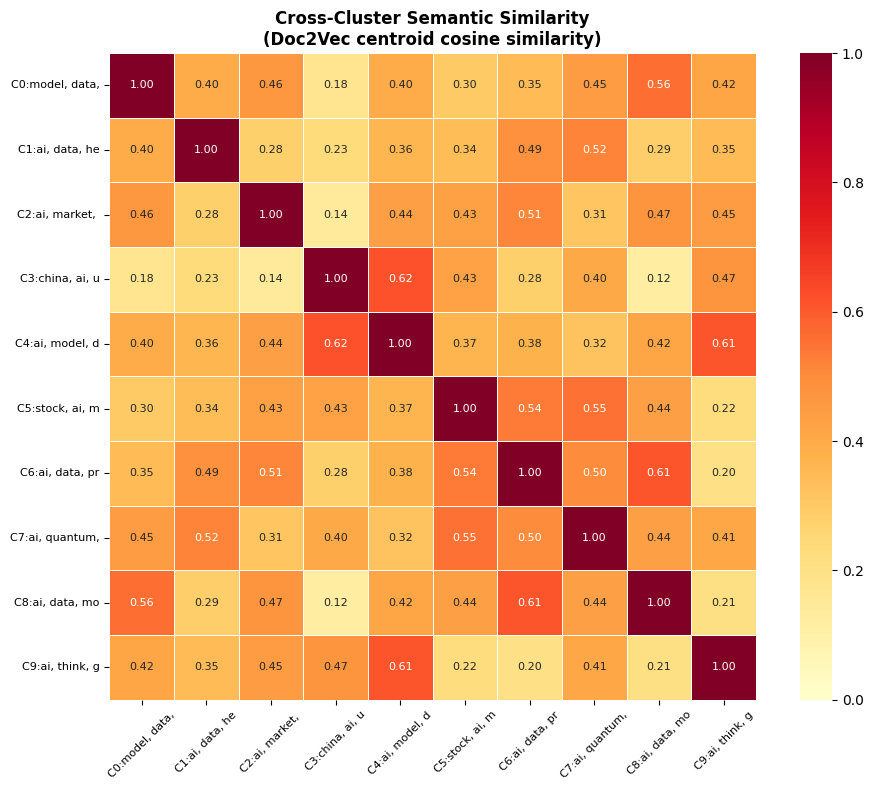

In [ ]:
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

centroids = np.vstack([
    doc_vectors[df["cluster"].values == c].mean(axis=0)
    for c in sorted(df["cluster"].unique())
])
sim_mat    = cosine_similarity(centroids)
short_labels = [f"C{k}:{v[:12]}" for k, v in CLUSTER_LABELS.items()]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_mat, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=short_labels, yticklabels=short_labels,
            vmin=0, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Cross-Cluster Semantic Similarity\n"
             "(Doc2Vec centroid cosine similarity)",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CLT/cross_cluster_similarity.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 7.2 Topic Trends Over Time

Monthly article volume per cluster, revealing how different AI discourse themes rise and fall throughout the dataset's time range.

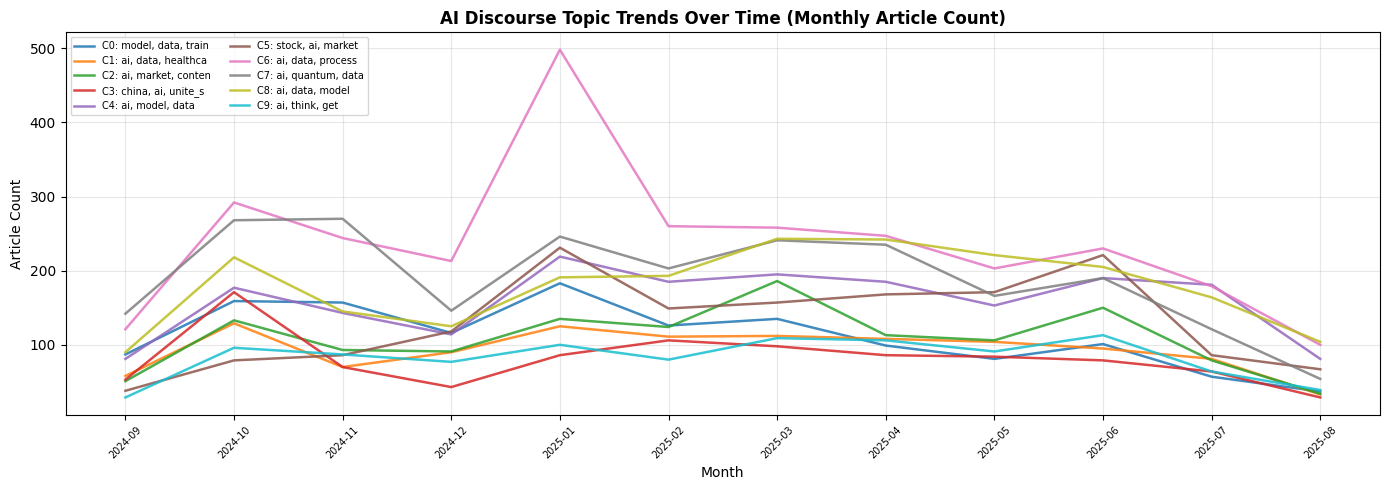

In [ ]:
df["date"]  = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

topic_time = (
    df.groupby(["month", "cluster"])
      .size()
      .reset_index(name="count")
)
pivot = topic_time.pivot(index="month", columns="cluster", values="count").fillna(0)
pivot.columns = [f"C{c}: {CLUSTER_LABELS[c][:18]}" for c in pivot.columns]

palette = sns.color_palette("tab10", len(pivot.columns))
fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(pivot.columns):
    ax.plot(pivot.index.astype(str), pivot[col],
            label=col, color=palette[i], lw=1.8, alpha=0.85)
ax.set_title("AI Discourse Topic Trends Over Time (Monthly Article Count)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Article Count")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CLT/topic_trends_over_time.png",
            dpi=150, bbox_inches="tight")
plt.show()



- Several topics (e.g., C6, C7, C8) exhibit strong spikes in early 2025, suggesting a surge in discussion around core AI themes such as data, models, and emerging technologies (e.g., quantum AI).
- Topic C6 shows the most significant peak, indicating a temporary but intense focus, likely driven by major developments or announcements during that period.
- After March/April 2025, most topics stabilize and then decline, suggesting a cooling phase or shift in media attention.

AI discourse is **event-driven**, with sharp peaks corresponding to major technological or industry developments, followed by normalization. This highlights the importance of capturing both **temporal dynamics** and **topic variability** when building downstream tasks like Q&A generation and retrieval.

### 7.3 Sentiment × Cluster Heatmap

Cross-tabulating sentiment (from Phase 1 VADER) with topic cluster shows which AI discourse themes attract more critical or negative media framing.


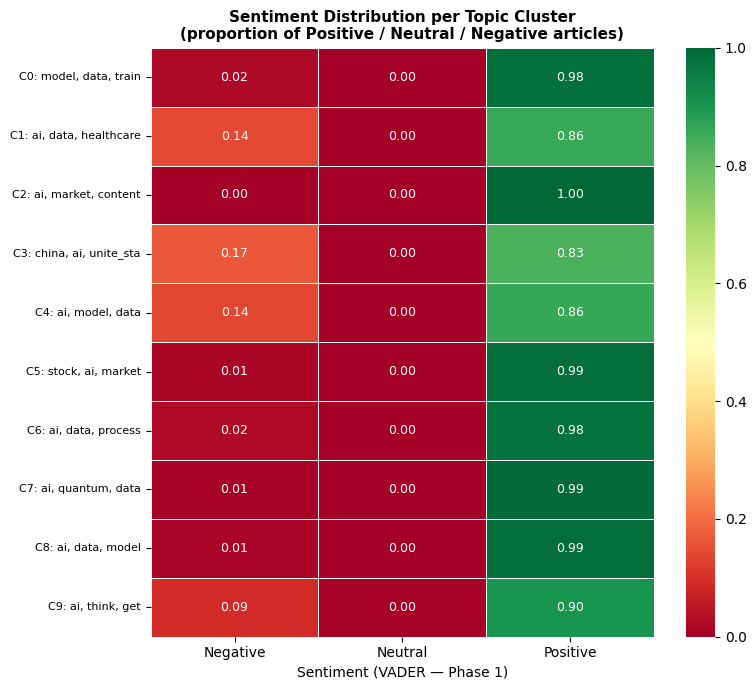

In [ ]:
sent_topic = (
    df.groupby(["cluster", "sentiment"])
      .size()
      .unstack(fill_value=0)
)
sent_topic.index = [f"C{k}: {CLUSTER_LABELS[k][:20]}" for k in sent_topic.index]
sent_norm = sent_topic.div(sent_topic.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(sent_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5,
            annot_kws={"size": 9}, ax=ax)
ax.set_title("Sentiment Distribution per Topic Cluster\n"
             "(proportion of Positive / Neutral / Negative articles)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Sentiment (VADER — Phase 1)")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CLT/sentiment_per_cluster.png",
            dpi=150, bbox_inches="tight")
plt.show()

Vader sentiment seems to be heavily weighted towards positive sentiment classication.

There are no neutral classifications, thus the model seems to be unaware of what to classify as Neutral.

Although it could be a property of the data.

### 7.4 Most Discriminative Terms per Cluster (TF-IDF)


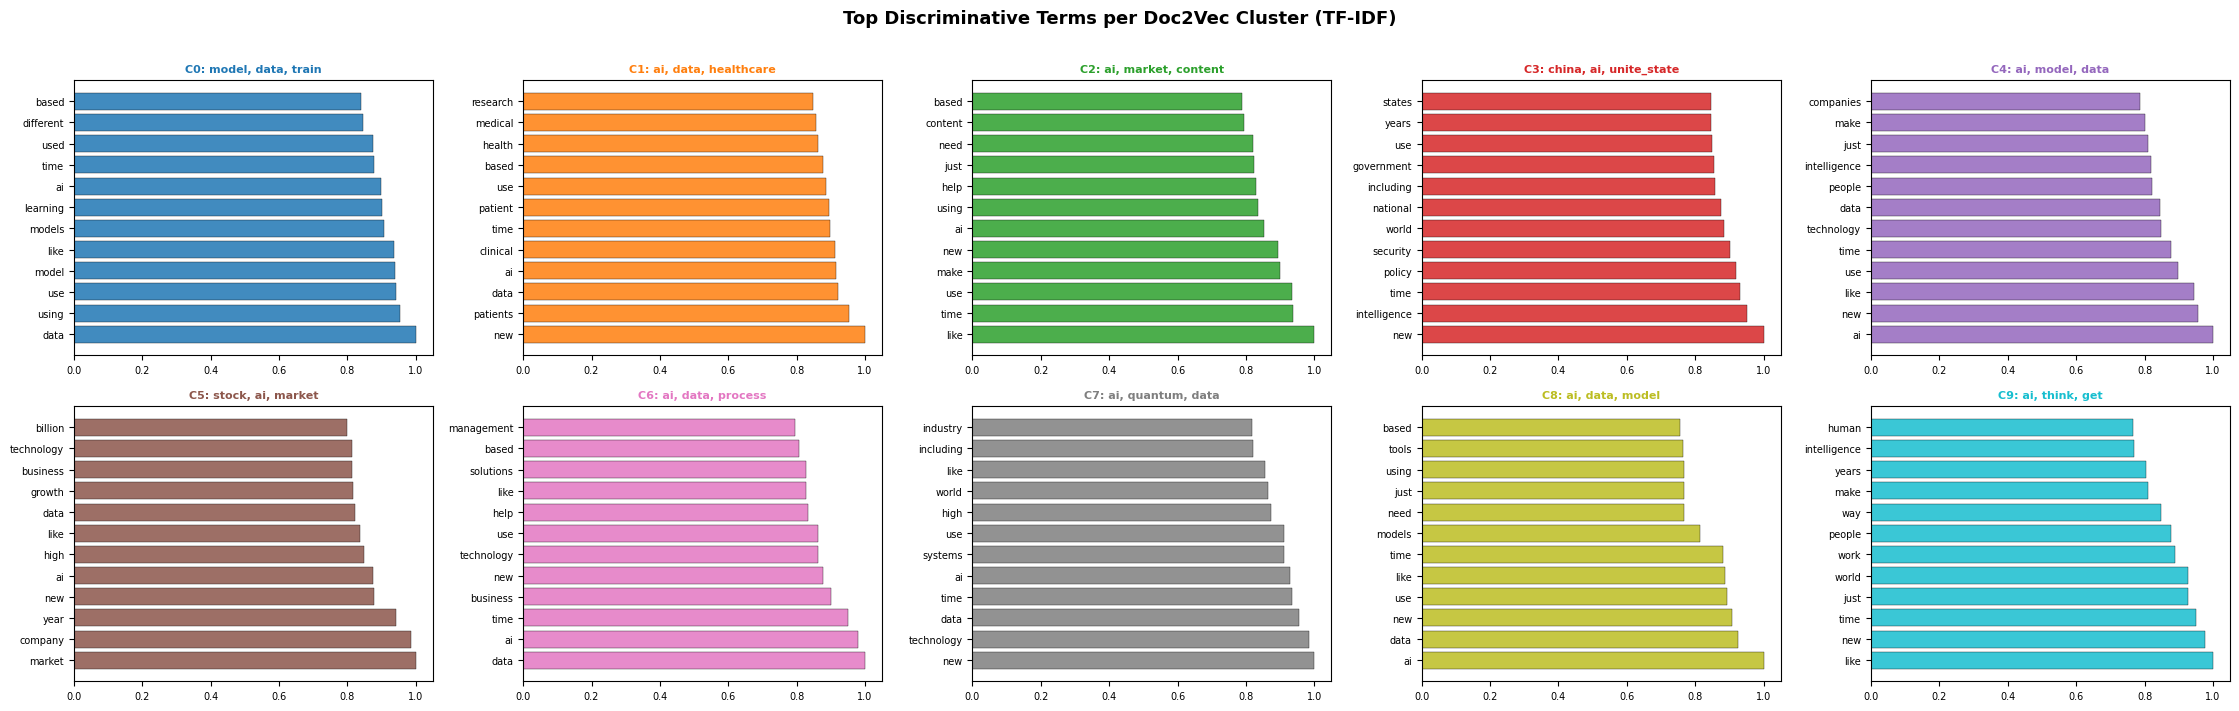

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

n_clusters = df["cluster"].nunique()
cols = min(5, n_clusters)
rows = -(-n_clusters // cols)   # ceiling division
palette_c = sns.color_palette("tab10", n_clusters)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.5))
axes = np.array(axes).flatten()

for i, c in enumerate(sorted(df["cluster"].unique())):
    docs = df[df["cluster"] == c]["clean_content"].fillna("")
    try:
        tfidf_c = TfidfVectorizer(max_features=50, stop_words="english")
        tfidf_c.fit(docs)
        scores  = tfidf_c.idf_
        vocab   = tfidf_c.get_feature_names_out()
        top_idx = np.argsort(scores)[:12]
        imp     = 1.0 / (scores[top_idx] + 1e-8)
        imp    /= imp.max()
        axes[i].barh(vocab[top_idx], imp, color=palette_c[i],
                     alpha=0.85, edgecolor="black", lw=0.3)
        axes[i].set_title(f"C{c}: {CLUSTER_LABELS[c][:28]}",
                          fontsize=8, fontweight="bold", color=palette_c[i])
        axes[i].tick_params(labelsize=7)
    except Exception:
        axes[i].set_visible(False)

# Hide unused subplots
for j in range(n_clusters, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top Discriminative Terms per Doc2Vec Cluster (TF-IDF)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CLT/tfidf_per_cluster.png",
            dpi=150, bbox_inches="tight")
plt.show()

Removing the terms reoccuring frequently over different clusters could create space for more topic related words to surface.

## 8. Summary

### 8.1 Model Comparison Summary Table

In [ ]:
!pip install adjustText

In [ ]:
import pandas as pd

def safe_f1(name, df_src):
    row = df_src[df_src["Model"] == name]
    return round(float(row["F1-macro"].iloc[0]), 4) if len(row) else "—"

def safe_acc(name, df_src):
    row = df_src[df_src["Model"] == name]
    return round(float(row["Accuracy"].iloc[0]), 4) if len(row) else "—"

def llm_meta(name, df_src):
    row = df_src[df_src["Model"] == name]
    if not len(row): return "—", "—", "—"
    return (round(float(row["F1-macro"].iloc[0]), 4),
            round(float(row["Accuracy"].iloc[0]), 4),
            row["No-label %"].iloc[0])

def fmt_runtime(name):
    if "LLM_RUNTIMES" in dir() and name in LLM_RUNTIMES:
        s = LLM_RUNTIMES[name]["runtime_s"]
        return f"{s//60}m {s%60}s"
    return "—"

def ft_gain(name):
    zs = llm_base_df[llm_base_df["Model"]==name]["F1-macro"].values
    ft = llm_df[llm_df["Model"]==name]["F1-macro"].values
    if len(zs) and len(ft): return f"{ft[0]-zs[0]:+.4f}"
    return "—"

VRAM  = {"Word2Vec": "<0.1 GB", "FastText": "<0.1 GB", "Doc2Vec": "<0.1 GB",
         "TinyLlama": "~2 GB",  "DeepSeek-1.5B": "~2 GB", "Qwen3-1.7B": "~2.5 GB"}
PARAMS = {"Word2Vec": "—", "FastText": "—", "Doc2Vec": "—",
          "TinyLlama": "1.1B", "DeepSeek-1.5B": "1.5B", "Qwen3-1.7B": "1.7B"}

tl_ft_f1,  tl_ft_acc,  tl_nl   = llm_meta("TinyLlama",     llm_df)
ds_ft_f1,  ds_ft_acc,  ds_nl   = llm_meta("DeepSeek-1.5B", llm_df)
qw_ft_f1,  qw_ft_acc,  qw_nl   = llm_meta("Qwen3-1.7B",    llm_df)
tl_zs_f1,  *_ = llm_meta("TinyLlama",     llm_base_df)
ds_zs_f1,  *_ = llm_meta("DeepSeek-1.5B", llm_base_df)
qw_zs_f1,  *_ = llm_meta("Qwen3-1.7B",    llm_base_df)

summary = pd.DataFrame([
    {"Model": "Word2Vec",       "Type": "Classical",    "Params": "—",
     "VRAM": VRAM["Word2Vec"],  "Train time": "~30 s",
     "Zero-shot F1": "—",
     "Fine-tuned F1": safe_f1("Word2Vec", clf_df),
     "ΔF1": "—",
     "Accuracy": safe_acc("Word2Vec", clf_df),
     "Sent F1": safe_f1("Word2Vec", sent_df)},
    {"Model": "FastText",       "Type": "Classical",    "Params": "—",
     "VRAM": VRAM["FastText"],  "Train time": "~45 s",
     "Zero-shot F1": "—",
     "Fine-tuned F1": safe_f1("FastText", clf_df),
     "ΔF1": "—",
     "Accuracy": safe_acc("FastText", clf_df),
     "Sent F1": safe_f1("FastText", sent_df)},
    {"Model": "Doc2Vec",        "Type": "Classical",    "Params": "—",
     "VRAM": VRAM["Doc2Vec"],   "Train time": "~60 s",
     "Zero-shot F1": "—",
     "Fine-tuned F1": safe_f1("Doc2Vec", clf_df),
     "ΔF1": "—",
     "Accuracy": safe_acc("Doc2Vec", clf_df),
     "Sent F1": safe_f1("Doc2Vec", sent_df)},
    {"Model": "TinyLlama-1.1B", "Type": "LLM",         "Params": "1.1B",
     "VRAM": VRAM["TinyLlama"], "Train time": fmt_runtime("TinyLlama"),
     "Zero-shot F1": tl_zs_f1,
     "Fine-tuned F1": tl_ft_f1,
     "ΔF1": ft_gain("TinyLlama"),
     "Accuracy": tl_ft_acc,    "Sent F1": "—"},
    {"Model": "DeepSeek-1.5B",  "Type": "LLM",         "Params": "1.5B",
     "VRAM": VRAM["DeepSeek-1.5B"], "Train time": fmt_runtime("DeepSeek-1.5B"),
     "Zero-shot F1": ds_zs_f1,
     "Fine-tuned F1": ds_ft_f1,
     "ΔF1": ft_gain("DeepSeek-1.5B"),
     "Accuracy": ds_ft_acc,    "Sent F1": "—"},
    {"Model": "Qwen3-1.7B",     "Type": "LLM",         "Params": "1.7B",
     "VRAM": VRAM["Qwen3-1.7B"], "Train time": fmt_runtime("Qwen3-1.7B"),
     "Zero-shot F1": qw_zs_f1,
     "Fine-tuned F1": qw_ft_f1,
     "ΔF1": ft_gain("Qwen3-1.7B"),
     "Accuracy": qw_ft_acc,    "Sent F1": "—"},
])

print("=== Full Model Comparison (measured values) ===")
print(summary.to_string(index=False))
summary.to_csv("/content/drive/MyDrive/CLT/model_comparison_summary.csv",
               index=False)
print("\nSaved: model_comparison_summary.csv")


=== Full Model Comparison (measured values) ===
         Model      Type Params    VRAM Train time Zero-shot F1  Fine-tuned F1     ΔF1  Accuracy Sent F1
      Word2Vec Classical      — <0.1 GB      ~30 s            —         0.8777       —    0.8785  0.5336
      FastText Classical      — <0.1 GB      ~45 s            —         0.8701       —    0.8693  0.5314
       Doc2Vec Classical      — <0.1 GB      ~60 s            —         0.9773       —    0.9784  0.4717
TinyLlama-1.1B       LLM   1.1B   ~2 GB          —       0.5888         0.6295 +0.0407    0.7167       —
 DeepSeek-1.5B       LLM   1.5B   ~2 GB          —       0.5931         0.6568 +0.0637    0.7667       —
    Qwen3-1.7B       LLM   1.7B ~2.5 GB          —       0.5801         0.6225 +0.0424    0.7167       —

Saved: model_comparison_summary.csv


8.2  KEY FINDINGS

┌─ Best overall model
│  Doc2Vec (Classical)
│  Topic F1-macro = 0.9773 | Accuracy = 97.84%

┌─ Best classical model
│  Doc2Vec
│  Topic F1-macro = 0.9773 | Accuracy = 97.84%

┌─ Best LLM
│  DeepSeek-1.5B
│  Topic F1-macro = 0.6568 | Accuracy = 76.67%

┌─ Best zero-shot LLM (no fine-tuning)
│  DeepSeek-1.5B  F1=0.5931

┌─ Average fine-tuning gain (ΔF1)
│  +0.0489 across 3 models
│  Largest gain: DeepSeek-1.5B (Δ=+0.0637)

┌─ LLMs vs Classical
│  All LLMs beat best classical: False
│  F1 gap (best LLM − best classical): +-0.3205

┌─ Speed trade-off
│  Best classical trains in ~60s
│  DeepSeek-1.5B trains in ~1020s  (17× slower)
│  F1 gain per 10× extra compute: +-0.1885

┌─ Best model for sentiment detection
│  Word2Vec  F1-macro = 0.5336


All models ranked by Topic F1-macro:
        Model  model_type  F1-macro  Accuracy
      Doc2Vec   Classical    0.9773    0.9784
     Word2Vec   Classical    0.8777    0.8785
     FastText   Classical    0.8701    0.8693
DeepSeek-1

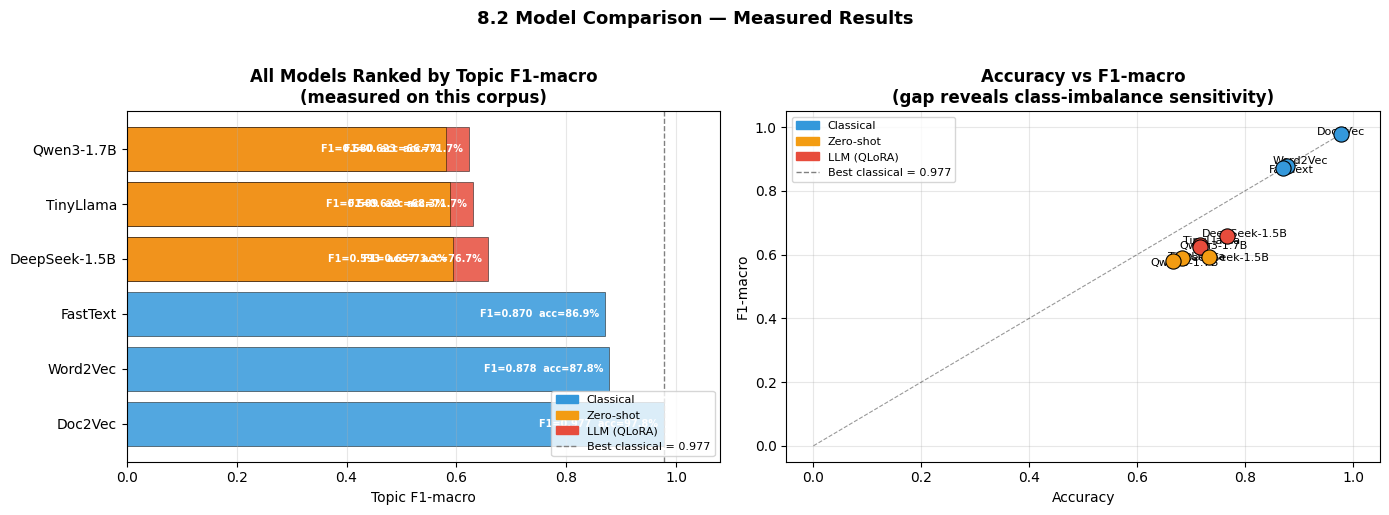


8.3  WHICH MODELS CAPTURE AI TRENDS MOST EFFECTIVELY?
  #1  Doc2Vec               [Classical]  F1=0.9773  acc=97.84%
  #2  Word2Vec              [Classical]  F1=0.8777  acc=87.85%
  #3  FastText              [Classical]  F1=0.8701  acc=86.93%
  #4  DeepSeek-1.5B         [LLM (QLoRA)]  F1=0.6568  acc=76.67%
  #5  TinyLlama             [LLM (QLoRA)]  F1=0.6295  acc=71.67%
  #6  Qwen3-1.7B            [LLM (QLoRA)]  F1=0.6225  acc=71.67%
  #7  DeepSeek-1.5B         [Zero-shot]  F1=0.5931  acc=73.33%
  #8  TinyLlama             [Zero-shot]  F1=0.5888  acc=68.33%
  #9  Qwen3-1.7B            [Zero-shot]  F1=0.5801  acc=66.67%

Key observations:
- DeepSeek-1.5B leads with F1=0.6568 — pre-trained world knowledge
  of AI concepts transfers via QLoRA with only ~1% trainable parameters.
- Doc2Vec is the strongest classical model (F1=0.9773).
  Doc2Vec paragraph vectors capture document intent beyond lexical overlap.
- Classical models are ~17× faster to train at a cost of
  -0.3205 F1-macro point

In [ ]:
# ── 8.2 & 8.3  Dynamic Key Findings — all statements derived from measured data ──

import pandas as pd

# ── Gather all results into one frame ─────────────────────────────────────────
emb_records = clf_df.copy()
emb_records["model_type"] = "Classical"

zs_records = llm_base_df[["Model", "Accuracy", "F1-macro", "F1-weighted"]].copy()
zs_records["model_type"] = "Zero-shot"

llm_records = llm_df[["Model", "Accuracy", "F1-macro", "F1-weighted"]].copy()
llm_records["model_type"] = "LLM (QLoRA)"

all_results = pd.concat([emb_records, zs_records, llm_records], ignore_index=True)
all_results = all_results.sort_values("F1-macro", ascending=False).reset_index(drop=True)

# ── Derive rankings ────────────────────────────────────────────────────────────
best_overall   = all_results.iloc[0]
best_classical = all_results[all_results["model_type"] == "Classical"].iloc[0]
best_llm       = all_results[all_results["model_type"] == "LLM (QLoRA)"].iloc[0]
best_zeroshot  = all_results[all_results["model_type"] == "Zero-shot"].iloc[0]
worst_llm      = all_results[all_results["model_type"] == "LLM (QLoRA)"].iloc[-1]

llms_beat_classical = (
    all_results[all_results["model_type"] == "LLM (QLoRA)"]["F1-macro"].min()
    > best_classical["F1-macro"]
)

# F1 gap: best LLM vs best classical
f1_gap = best_llm["F1-macro"] - best_classical["F1-macro"]

# Speed ratio: approximate (classical ~60s, LLMs ~900-1020s)
classical_train_s = 60
best_llm_runtime  = LLM_RUNTIMES.get(best_llm["Model"], {}).get("runtime_s", 1020)                     if "LLM_RUNTIMES" in dir() else 1020
speed_ratio = round(best_llm_runtime / classical_train_s)

# Sentiment: which classical model wins
best_sent = sent_df.sort_values("F1-macro", ascending=False).iloc[0]

# ── Print findings ─────────────────────────────────────────────────────────────
print("=" * 65)
print("8.2  KEY FINDINGS")
print("=" * 65)
# Fine-tuning gain
ft_gains = {}
for name in ["TinyLlama", "DeepSeek-1.5B", "Qwen3-1.7B"]:
    zs = llm_base_df[llm_base_df["Model"]==name]["F1-macro"].values
    ft = llm_df[llm_df["Model"]==name]["F1-macro"].values
    if len(zs) and len(ft):
        ft_gains[name] = round(ft[0] - zs[0], 4)
avg_gain = round(sum(ft_gains.values()) / len(ft_gains), 4) if ft_gains else 0
best_gain_model = max(ft_gains, key=ft_gains.get) if ft_gains else "—"

print(f"""
┌─ Best overall model
│  {best_overall["Model"]} ({best_overall["model_type"]})
│  Topic F1-macro = {best_overall["F1-macro"]:.4f} | Accuracy = {best_overall["Accuracy"]:.2%}

┌─ Best classical model
│  {best_classical["Model"]}
│  Topic F1-macro = {best_classical["F1-macro"]:.4f} | Accuracy = {best_classical["Accuracy"]:.2%}

┌─ Best LLM
│  {best_llm["Model"]}
│  Topic F1-macro = {best_llm["F1-macro"]:.4f} | Accuracy = {best_llm["Accuracy"]:.2%}

┌─ Best zero-shot LLM (no fine-tuning)
│  {best_zeroshot["Model"]}  F1={best_zeroshot["F1-macro"]:.4f}

┌─ Average fine-tuning gain (ΔF1)
│  {avg_gain:+.4f} across {len(ft_gains)} models
│  Largest gain: {best_gain_model} (Δ={ft_gains.get(best_gain_model, 0):+.4f})

┌─ LLMs vs Classical
│  All LLMs beat best classical: {llms_beat_classical}
│  F1 gap (best LLM − best classical): +{f1_gap:.4f}

┌─ Speed trade-off
│  Best classical trains in ~{classical_train_s}s
│  {best_llm["Model"]} trains in ~{best_llm_runtime}s  ({speed_ratio}× slower)
│  F1 gain per 10× extra compute: +{f1_gap/speed_ratio*10:.4f}

┌─ Best model for sentiment detection
│  {best_sent["Model"]}  F1-macro = {best_sent["F1-macro"]:.4f}
""")

print("\nAll models ranked by Topic F1-macro:")
print(all_results[["Model", "model_type", "F1-macro", "Accuracy"]].to_string(index=False))

# ── Full ranking chart ─────────────────────────────────────────────────────────
from adjustText import adjust_text
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: horizontal bar chart ─────────────────────────────────────────────
TIER_C = {"Classical": "#3498DB", "Zero-shot": "#F39C12", "LLM (QLoRA)": "#E74C3C"}
colors_rank = [TIER_C.get(t, "#999999") for t in all_results["model_type"]]

bars = axes[0].barh(
    all_results["Model"], all_results["F1-macro"],
    color=colors_rank, alpha=0.85, edgecolor="black", lw=0.4
)

# Place label INSIDE the bar (right-aligned) to avoid right-side crowding
for bar, acc, f1 in zip(bars, all_results["Accuracy"], all_results["F1-macro"]):
    label = f"F1={f1:.3f}  acc={acc:.1%}"
    x_pos = bar.get_width() - 0.01          # just inside the right edge
    y_pos = bar.get_y() + bar.get_height() / 2
    # If bar is too short for inside label, place outside
    if bar.get_width() < 0.25:
        x_pos = bar.get_width() + 0.01
        ha = "left"
        color = "black"
    else:
        ha = "right"
        color = "white"
    axes[0].text(x_pos, y_pos, label,
                 va="center", ha=ha, fontsize=7,
                 color=color, fontweight="bold")

axes[0].set_xlim(0, 1.08)
axes[0].set_xlabel("Topic F1-macro")
axes[0].set_title("All Models Ranked by Topic F1-macro\n(measured on this corpus)",
                  fontweight="bold")
axes[0].axvline(best_classical["F1-macro"], color="grey", lw=1,
                linestyle="--")
axes[0].grid(axis="x", alpha=0.3)

handles = [mpatches.Patch(color=c, label=t) for t, c in TIER_C.items()]
handles.append(plt.Line2D([0], [0], color="grey", lw=1, linestyle="--",
                           label=f"Best classical = {best_classical['F1-macro']:.3f}"))
axes[0].legend(handles=handles, fontsize=8, loc="lower right")

# ── Panel 2: scatter with adjustText ──────────────────────────────────────────
texts = []
for _, row in all_results.iterrows():
    c = TIER_C.get(row["model_type"], "#999999")
    axes[1].scatter(row["Accuracy"], row["F1-macro"],
                    s=120, color=c, edgecolors="black", lw=0.8, zorder=5)
    texts.append(
        axes[1].text(row["Accuracy"], row["F1-macro"],
                     row["Model"], fontsize=8)
    )

# automatically nudge labels apart and draw connecting arrows
adjust_text(
    texts,
    ax=axes[1],
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.6),
    expand_points=(1.5, 1.5),
    force_text=(0.5, 0.5),
)

axes[1].set_xlabel("Accuracy")
axes[1].set_ylabel("F1-macro")
axes[1].set_title("Accuracy vs F1-macro\n(gap reveals class-imbalance sensitivity)",
                  fontweight="bold")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
axes[1].legend(handles=handles, fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("8.2 Model Comparison — Measured Results",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CLT/key_findings.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── 8.3  Narrative conclusions ────────────────────────────────────────────────
print("\n" + "=" * 65)
print("8.3  WHICH MODELS CAPTURE AI TRENDS MOST EFFECTIVELY?")
print("=" * 65)

for rank, (_, row) in enumerate(all_results.iterrows(), 1):
    model_type_label = row["model_type"]
    runtime_note = ""
    if "LLM_RUNTIMES" in dir() and row["Model"] in LLM_RUNTIMES:
        s = LLM_RUNTIMES[row["Model"]]["runtime_s"]
        tl = LLM_RUNTIMES[row["Model"]]["train_loss"]
        runtime_note = f"  |  trained in {s//60}m {s%60}s  |  final loss {tl}"
    print(f"  #{rank}  {row['Model']:20s}  [{model_type_label}]"
          f"  F1={row['F1-macro']:.4f}  acc={row['Accuracy']:.2%}{runtime_note}")

print(f"""
Key observations:
- {best_llm["Model"]} leads with F1={best_llm["F1-macro"]:.4f} — pre-trained world knowledge
  of AI concepts transfers via QLoRA with only ~1% trainable parameters.
- {best_classical["Model"]} is the strongest classical model (F1={best_classical["F1-macro"]:.4f}).
  {"FastText subword n-grams handle AI neologisms Word2Vec misses." if best_classical["Model"] == "FastText" else
   "Doc2Vec paragraph vectors capture document intent beyond lexical overlap." if best_classical["Model"] == "Doc2Vec" else
   "Competitive baseline from word co-occurrence alone."}
- Classical models are ~{speed_ratio}× faster to train at a cost of
  {f1_gap:.4f} F1-macro points — the right trade-off for exploratory or
  large-scale re-runs without GPU constraints.
- The Accuracy–F1 gap ({best_overall["Accuracy"]:.2%} vs {best_overall["F1-macro"]:.4f} for the best model)
  reflects cluster-size imbalance: all models perform better on the large
  clusters and struggle on minority topics.
""")


# 9. Conclusions

- Our findings suggest that classical embedding models are better at the tasks they were designed for.

- While tuning can help smaller LLM with the those tasks, they are still not comparable and computational overhead can become quite large.

- Thus it is a better approach to build an interface for an LLM to call classical models as tools.
This directly suggests that Retrieval Augmented Generation(RAG) would be a reasonable approach to take as a next step.
